# Problem

Over a time, A company  have recongnized that their customers are churning in result making loss to company.So they want to track that which customers are likly to leave and what are factors of churning.
Company wants to make a model that can predict whether the customer will churn or not ,so ***Suprvised Machine Learning Classification Model*** need to be made and for company ***recall*** is evaluating metrics.
This model will help to recongnize which customer likely to churn and can be avoided on given factors .

# Import Libraries

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,recall_score,classification_report,f1_score,precision_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
import pickle
from sklearn.preprocessing import MinMaxScaler
from datetime import datetime,timedelta
from sklearn.pipeline import Pipeline

# Loading Dataset

We have customer churn Dataset from company.

In [2]:
churn_data=pd.read_csv("churn_dataset.csv")

In [3]:
churn_data.shape

(36992, 23)

# Data Analysis

In [4]:
churn_data.head()

,age,gender,security_no,region_category,membership_category,joining_date,joined_through_referral,referral_id,preferred_offer_types,medium_of_operation,...,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn_risk_score
0,NaN,F,XW0DQ7H,NaN,Platinum Membership,17-08-2017,NaN,xxxxxxxx,Gift Vouchers/Coupons,?,...,NaN,NaN,17,NaN,Yes,Yes,No,Not Applicable,Products always in Stock,0
1,32.0,F,5K0N3X1,City,NaN,28-08-2017,?,CID21329,Gift Vouchers/Coupons,Desktop,...,NaN,NaN,10,NaN,Yes,No,Yes,NaN,Quality Customer Care,0
2,44.0,F,1F2TCL3,NaN,NaN,11-11-2016,Yes,CID12313,NaN,Desktop,...,NaN,NaN,22,NaN,No,Yes,NaN,NaN,Poor Website,1
3,37.0,M,VJGJ33N,City,No Membership,29-10-2016,Yes,CID3793,NaN,Desktop,...,53.27,25239.56,6,567.66,NaN,Yes,Yes,Unsolved,NaN,1
4,NaN,NaN,SVZXCWB,NaN,NaN,12-09-2017,No,xxxxxxxx,Credit/Debit Card Offers,Smartphone,...,113.13,24483.66,16,NaN,NaN,Yes,NaN,Solved,Poor Website,1


In [5]:
churn_data.tail()

,age,gender,security_no,region_category,membership_category,joining_date,joined_through_referral,referral_id,preferred_offer_types,medium_of_operation,...,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn_risk_score
36987,NaN,F,6F51HFO,NaN,NaN,21-09-2017,No,xxxxxxxx,Credit/Debit Card Offers,Desktop,...,-650.682758,27277.68,NaN,NaN,No,Yes,Yes,No Information Available,NaN,1
36988,NaN,F,21KSM8Y,Town,Basic Membership,27-06-2016,No,NaN,NaN,Smartphone,...,-638.123421,NaN,28,527.990000,Yes,No,NaN,NaN,Poor Customer Service,1
36989,23.0,NaN,XK1IM9H,NaN,Basic Membership,NaN,Yes,CID3838,NaN,Desktop,...,154.940000,38127.56,Error,680.470000,NaN,Yes,Yes,NaN,Poor Website,1
36990,53.0,M,K6VTP1Z,Village,Platinum Membership,15-06-2017,No,NaN,Gift Vouchers/Coupons,Smartphone,...,NaN,2378.86,20,197.264414,NaN,Yes,No,Not Applicable,NaN,0
36991,NaN,NaN,LBX0GLR,NaN,Silver Membership,23-10-2015,NaN,xxxxxxxx,Gift Vouchers/Coupons,Desktop,...,79.180000,2189.68,Error,719.970000,Yes,No,No,Not Applicable,Quality Customer Care,0


In [6]:
churn_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36992 entries, 0 to 36991
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   age                           26823 non-null  float64
 1   gender                        24579 non-null  object 
 2   security_no                   29188 non-null  object 
 3   region_category               19650 non-null  object 
 4   membership_category           22915 non-null  object 
 5   joining_date                  28919 non-null  object 
 6   joined_through_referral       23543 non-null  object 
 7   referral_id                   28124 non-null  object 
 8   preferred_offer_types         26027 non-null  object 
 9   medium_of_operation           28968 non-null  object 
 10  internet_option               27798 non-null  object 
 11  last_visit_time               28253 non-null  object 
 12  days_since_last_login         26555 non-null  float64
 13  a

In [7]:
churn_data.describe()

,age,days_since_last_login,avg_time_spent,avg_transaction_value,points_in_wallet,churn_risk_score
count,26823.000000,26555.000000,22345.000000,22516.000000,23568.000000,36992.000000
mean,37.060582,-41.904011,242.413588,29426.309546,686.446644,0.540982
std,15.870626,228.824174,398.309447,19591.656892,193.329352,0.498324
min,10.000000,-999.000000,-2814.109110,804.340000,-483.856401,0.000000
25%,23.000000,8.000000,59.840000,14233.495000,615.685000,0.000000
50%,37.000000,12.000000,161.070000,27692.225000,697.790000,1.000000
75%,51.000000,16.000000,354.310000,40893.710000,763.782500,1.000000
max,64.000000,26.000000,3235.578521,99914.050000,2069.069761,1.000000


In [8]:
pd.set_option('display.max_columns',None)

# Exploratory Data Analysis and Data Cleaning

We will do EDA and based on EDA, we will handle missing values and we will also handle the columns that are not factors for the churning risk of Company.

## Data Analysis and Feature Separation

### Analysis

In [9]:
churn_data_1=churn_data.copy()

In [10]:
churn_data_1.head()

,age,gender,security_no,region_category,membership_category,joining_date,joined_through_referral,referral_id,preferred_offer_types,medium_of_operation,internet_option,last_visit_time,days_since_last_login,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn_risk_score
0,NaN,F,XW0DQ7H,NaN,Platinum Membership,17-08-2017,NaN,xxxxxxxx,Gift Vouchers/Coupons,?,NaN,NaN,17.0,NaN,NaN,17,NaN,Yes,Yes,No,Not Applicable,Products always in Stock,0
1,32.0,F,5K0N3X1,City,NaN,28-08-2017,?,CID21329,Gift Vouchers/Coupons,Desktop,Mobile_Data,12:38:13,16.0,NaN,NaN,10,NaN,Yes,No,Yes,NaN,Quality Customer Care,0
2,44.0,F,1F2TCL3,NaN,NaN,11-11-2016,Yes,CID12313,NaN,Desktop,Wi-Fi,22:53:21,14.0,NaN,NaN,22,NaN,No,Yes,NaN,NaN,Poor Website,1
3,37.0,M,VJGJ33N,City,No Membership,29-10-2016,Yes,CID3793,NaN,Desktop,Mobile_Data,15:57:50,11.0,53.27,25239.56,6,567.66,NaN,Yes,Yes,Unsolved,NaN,1
4,NaN,NaN,SVZXCWB,NaN,NaN,12-09-2017,No,xxxxxxxx,Credit/Debit Card Offers,Smartphone,NaN,15:46:44,20.0,113.13,24483.66,16,NaN,NaN,Yes,NaN,Solved,Poor Website,1


In [11]:
null_count=churn_data_1.isnull().sum()
null_count

age                             10169
gender                          12413
security_no                      7804
region_category                 17342
membership_category             14077
joining_date                     8073
joined_through_referral         13449
referral_id                      8868
preferred_offer_types           10965
medium_of_operation              8024
internet_option                  9194
last_visit_time                  8739
days_since_last_login           10437
avg_time_spent                  14647
avg_transaction_value           14476
avg_frequency_login_days        14133
points_in_wallet                13424
used_special_discount           12844
offer_application_preference     9105
past_complaint                   9422
complaint_status                10475
feedback                         8369
churn_risk_score                    0
dtype: int64

### Handling Anomalous Values

As we have columns ***joined_through_referral*** and ***medium_of_operation*** have anomalous so we will replace it with null value so that we can handle them later on easily. Column ***days_since_last_login*** that contains -999 values which also indicates null value so we replace those ones with null values also.

In [12]:
churn_data_1=churn_data_1.replace("?",np.nan)
churn_data_1["days_since_last_login"]=churn_data_1["days_since_last_login"].replace(-999,np.nan)
churn_data_1["days_since_last_login"]=churn_data_1["days_since_last_login"].abs()
churn_data_1["avg_time_spent"]=churn_data_1["avg_time_spent"].abs()
churn_data_1["gender"]=churn_data_1["gender"].replace("Unknown",np.nan)

### Handling Anomalous Values

We also have anomalous values in ***avg_frequency_login_days*** columns,so we will replace them with null values and it also contains the negative values which are by mistake, so we will also replace those one with absolute.

In [13]:
churn_data_1=churn_data_1.replace("Error",np.nan)
churn_data_1["avg_frequency_login_days"]=churn_data_1["avg_frequency_login_days"].astype("float64")
churn_data_1["avg_frequency_login_days"]=churn_data_1["avg_frequency_login_days"].abs()

In [14]:
churn_data_1.head()

,age,gender,security_no,region_category,membership_category,joining_date,joined_through_referral,referral_id,preferred_offer_types,medium_of_operation,internet_option,last_visit_time,days_since_last_login,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn_risk_score
0,NaN,F,XW0DQ7H,NaN,Platinum Membership,17-08-2017,NaN,xxxxxxxx,Gift Vouchers/Coupons,NaN,NaN,NaN,17.0,NaN,NaN,17.0,NaN,Yes,Yes,No,Not Applicable,Products always in Stock,0
1,32.0,F,5K0N3X1,City,NaN,28-08-2017,NaN,CID21329,Gift Vouchers/Coupons,Desktop,Mobile_Data,12:38:13,16.0,NaN,NaN,10.0,NaN,Yes,No,Yes,NaN,Quality Customer Care,0
2,44.0,F,1F2TCL3,NaN,NaN,11-11-2016,Yes,CID12313,NaN,Desktop,Wi-Fi,22:53:21,14.0,NaN,NaN,22.0,NaN,No,Yes,NaN,NaN,Poor Website,1
3,37.0,M,VJGJ33N,City,No Membership,29-10-2016,Yes,CID3793,NaN,Desktop,Mobile_Data,15:57:50,11.0,53.27,25239.56,6.0,567.66,NaN,Yes,Yes,Unsolved,NaN,1
4,NaN,NaN,SVZXCWB,NaN,NaN,12-09-2017,No,xxxxxxxx,Credit/Debit Card Offers,Smartphone,NaN,15:46:44,20.0,113.13,24483.66,16.0,NaN,NaN,Yes,NaN,Solved,Poor Website,1


### Null Values Analysis

We will analyse the null values in each columns,through which we will find percentage of them and then we can handle them based on their percentage.

In [15]:
churn_data_1.isnull().sum()

age                             10169
gender                          12451
security_no                      7804
region_category                 17342
membership_category             14077
joining_date                     8073
joined_through_referral         16898
referral_id                      8868
preferred_offer_types           10965
medium_of_operation             12250
internet_option                  9194
last_visit_time                  8739
days_since_last_login           11872
avg_time_spent                  14647
avg_transaction_value           14476
avg_frequency_login_days        16343
points_in_wallet                13424
used_special_discount           12844
offer_application_preference     9105
past_complaint                   9422
complaint_status                10475
feedback                         8369
churn_risk_score                    0
dtype: int64

In [16]:
null_percent=(churn_data_1.isnull().sum()*100)/churn_data_1.shape[0]
null_percent

age                             27.489728
gender                          33.658629
security_no                     21.096453
region_category                 46.880407
membership_category             38.054174
joining_date                    21.823638
joined_through_referral         45.680147
referral_id                     23.972751
preferred_offer_types           29.641544
medium_of_operation             33.115268
internet_option                 24.854022
last_visit_time                 23.624027
days_since_last_login           32.093426
avg_time_spent                  39.595048
avg_transaction_value           39.132785
avg_frequency_login_days        44.179823
points_in_wallet                36.288927
used_special_discount           34.721021
offer_application_preference    24.613430
past_complaint                  25.470372
complaint_status                28.316933
feedback                        22.623811
churn_risk_score                 0.000000
dtype: float64

<Axes: >

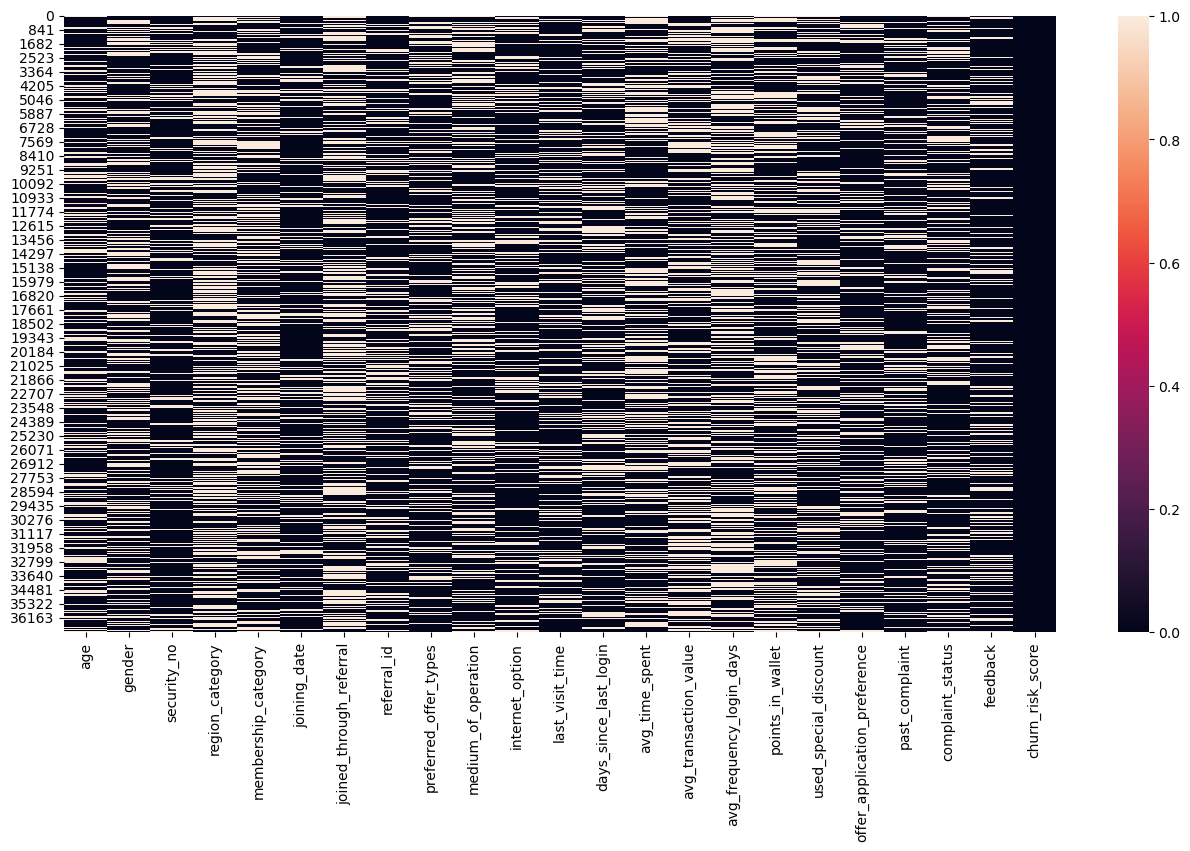

In [17]:
plt.figure(figsize=(16,8))
sns.heatmap(churn_data_1.isnull())

Given Heatmap shows that we have null values in each columns except the ***churn_risk_score*** ,so we need to handle all them. 

### Separating The Features

To handle the missing values we have to divide our data into numerical and categorical features ,which will help us out for handling.

In [18]:
churn_data_2=churn_data_1.copy()

In [19]:
num_features=churn_data_2.select_dtypes("number")
num_features

,age,days_since_last_login,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,churn_risk_score
0,NaN,17.0,NaN,NaN,17.0,NaN,0
1,32.0,16.0,NaN,NaN,10.0,NaN,0
2,44.0,14.0,NaN,NaN,22.0,NaN,1
3,37.0,11.0,53.270000,25239.56,6.0,567.660000,1
4,NaN,20.0,113.130000,24483.66,16.0,NaN,1
...,...,...,...,...,...,...,...
36987,NaN,NaN,650.682758,27277.68,NaN,NaN,1
36988,NaN,NaN,638.123421,NaN,28.0,527.990000,1
36989,23.0,12.0,154.940000,38127.56,NaN,680.470000,1
36990,53.0,15.0,NaN,2378.86,20.0,197.264414,0


In [20]:
cat_features=churn_data_2.select_dtypes("object")
cat_features

,gender,security_no,region_category,membership_category,joining_date,joined_through_referral,referral_id,preferred_offer_types,medium_of_operation,internet_option,last_visit_time,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback
0,F,XW0DQ7H,NaN,Platinum Membership,17-08-2017,NaN,xxxxxxxx,Gift Vouchers/Coupons,NaN,NaN,NaN,Yes,Yes,No,Not Applicable,Products always in Stock
1,F,5K0N3X1,City,NaN,28-08-2017,NaN,CID21329,Gift Vouchers/Coupons,Desktop,Mobile_Data,12:38:13,Yes,No,Yes,NaN,Quality Customer Care
2,F,1F2TCL3,NaN,NaN,11-11-2016,Yes,CID12313,NaN,Desktop,Wi-Fi,22:53:21,No,Yes,NaN,NaN,Poor Website
3,M,VJGJ33N,City,No Membership,29-10-2016,Yes,CID3793,NaN,Desktop,Mobile_Data,15:57:50,NaN,Yes,Yes,Unsolved,NaN
4,NaN,SVZXCWB,NaN,NaN,12-09-2017,No,xxxxxxxx,Credit/Debit Card Offers,Smartphone,NaN,15:46:44,NaN,Yes,NaN,Solved,Poor Website
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36987,F,6F51HFO,NaN,NaN,21-09-2017,No,xxxxxxxx,Credit/Debit Card Offers,Desktop,NaN,NaN,No,Yes,Yes,No Information Available,NaN
36988,F,21KSM8Y,Town,Basic Membership,27-06-2016,No,NaN,NaN,Smartphone,Wi-Fi,23:18:31,Yes,No,NaN,NaN,Poor Customer Service
36989,NaN,XK1IM9H,NaN,Basic Membership,NaN,Yes,CID3838,NaN,Desktop,Wi-Fi,3:50:25,NaN,Yes,Yes,NaN,Poor Website
36990,M,K6VTP1Z,Village,Platinum Membership,15-06-2017,No,NaN,Gift Vouchers/Coupons,Smartphone,Mobile_Data,9:50:03,NaN,Yes,No,Not Applicable,NaN


### Visualize The Churn Risk Score

We will analyse the churn risk score ,in order to check if our dataset is balanced ,if it is not balanced then we need to balance it.

([<matplotlib.patches.Wedge at 0x1885adb1940>,
 [Text(-0.1412321088271773, 1.0908957289476517, '1'),
  Text(0.14123181406159502, -1.0908957671092463, '0')],
 [Text(-0.07703569572391489, 0.5950340339714464, '54.1%'),
  Text(0.07703553494268818, -0.5950340547868616, '45.9%')])

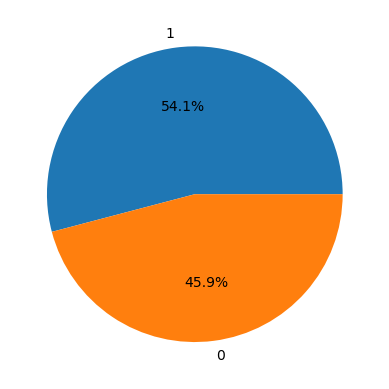

In [21]:
count=churn_data_2["churn_risk_score"].value_counts()
plt.pie(count,
        autopct="%1.1f%%",labels=count.index)

As we can see our database is balance so we don't need to do any kind of changes or we don't need to remove or add rows to make it balanced.

## Handling Numerical_Features

### Separation On Percentage

Now we will check the percentage of null value if the % of null values is greater than 50 then we will consider if we can remove that column and if it is less than 50% then we will use Mean/Average for handling.

In [22]:
null_percent_num=(num_features.isnull().sum()*100)/num_features.shape[0]
null_percent_num

age                         27.489728
days_since_last_login       32.093426
avg_time_spent              39.595048
avg_transaction_value       39.132785
avg_frequency_login_days    44.179823
points_in_wallet            36.288927
churn_risk_score             0.000000
dtype: float64

In [23]:
null_feature_50=null_percent_num[null_percent>50]
null_feature_50

Series([], dtype: float64)

So we donot have any data having more than 50% null value ,so we will drop any columns based on percentage.

In [24]:
null_feature_less_50=null_percent_num[null_percent<=50]
null_feature_less_50

age                         27.489728
days_since_last_login       32.093426
avg_time_spent              39.595048
avg_transaction_value       39.132785
avg_frequency_login_days    44.179823
points_in_wallet            36.288927
churn_risk_score             0.000000
dtype: float64

As we can see we dont have any Columnn that have more than 50% null values for for Each column of number we will replace null with Mean.

### Function to show the Graph

We have to make a function to show the graph of our numerical Features before Imputation and after Imputation.

In [25]:
def show_graph(data,data_new):
    plt.figure(figsize=(8,2))
    plt.subplot(1,2,1)
    sns.histplot(data=data,bins=40,color="red",kde=True)
    plt.title("Before Handling")
    plt.subplot(1,2,2)
    sns.histplot(data=data_new,bins=40,color="red",kde=True)
    plt.title("After Handling")
    plt.tight_layout()
    plt.show()
    plt.figure(figsize=(8,2))
    plt.subplot(1,2,1)
    sns.boxplot(x=data)
    plt.title("Before Handling")
    plt.subplot(1,2,2)
    sns.boxplot(x=data_new)
    plt.title("After Handling")
    plt.tight_layout()
    plt.show()

### Age Data Preprocessing

We have 27.48% missing values for ***age*** so we will imputate it by mean.

0


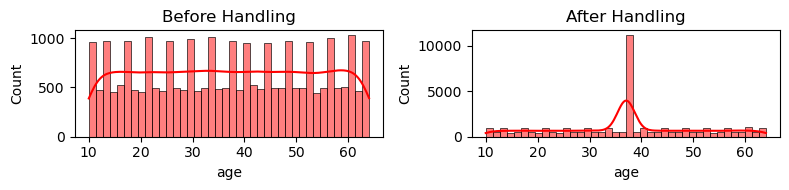

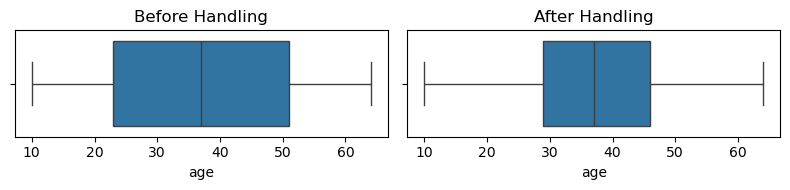

In [26]:
age_mean=churn_data_2["age"].mean()
churn_data_2["age"]=churn_data_2["age"].fillna(age_mean)
print(churn_data_2["age"].isnull().sum())

# Show the Graph
show_graph(churn_data_1["age"],churn_data_2["age"])

Here we can conclude that in age we don't have any kind of ***Outlier*** in our data and our data mostly lies at average **36** that indicates most of our customers are from Adult category.

#### Age vs. Churn Risk Analysis

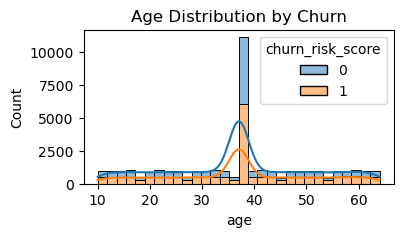

In [27]:
# Plot the graph age vs churn_risk_score
plt.figure(figsize=(4,2))
plt.subplot(1,1,1)
sns.histplot(data=churn_data_2,
             x="age",
             hue="churn_risk_score",
             bins=30,
             kde=True,
             multiple="stack")

plt.title("Age Distribution by Churn")
plt.show()


Here we have most customers of average age 35 to 40 and we also have high at this age which cause us to more careful about this and for age very less or very aged we don't have that much customers.

### Days_since_last_login Data Preprocessing

We have 32.09% missing value which can be handled by mean,so we will use mean to handle this one.

0


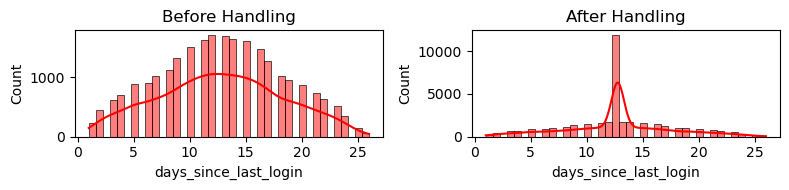

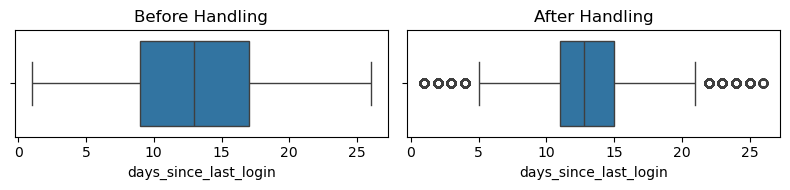

In [28]:
# days_since_last_login 28.214208% Null value
days_since_last_login_mean=churn_data_2["days_since_last_login"].mean()
churn_data_2["days_since_last_login"]=churn_data_2["days_since_last_login"].fillna(days_since_last_login_mean)
print(churn_data_2["days_since_last_login"].isnull().sum())

# Show the graph
show_graph(churn_data_1["days_since_last_login"],churn_data_2["days_since_last_login"])

As we can see we have very small number of Outliers,as their number is too low as compared with our dataset ,that's why it is not going to affect our model that much.so we don't need to handle this one.

#### Days_since_last_login vs Churn Risk Analysis

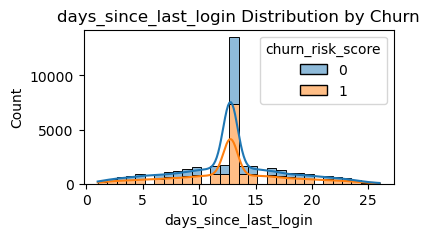

In [29]:
# Plot the graph age vs days_since_last_login
plt.figure(figsize=(4,2))
plt.subplot(1,1,1)
sns.histplot(data=churn_data_2,
             x="days_since_last_login",
             hue="churn_risk_score",
             bins=30,
             kde=True,
             multiple="stack")

plt.title("days_since_last_login Distribution by Churn")
plt.show()


On average every cutomer come back to website after 13 or 14 days and for those days we have very high churn risk.So it looks like website need to be optimized every two weeks.

### Avg_time_spent Data Preprocessing

As we have 39.59% null values so we will imputate it with mode because we have many outliers, so in order to avoid from the affect of outlier we need to use mode instead of mean.

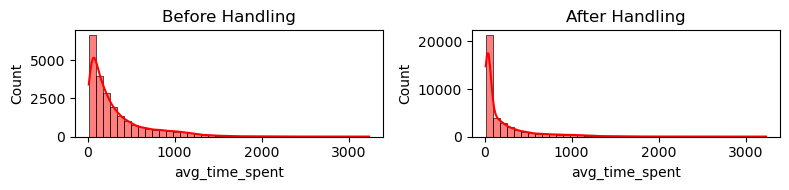

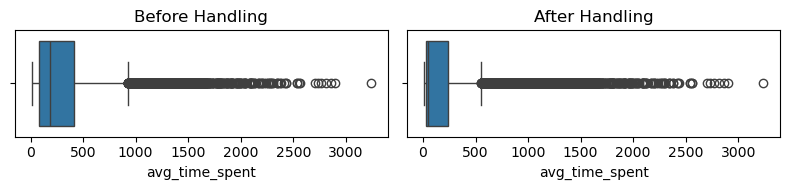

In [30]:
avg_time_mean=churn_data_2["avg_time_spent"].mode()[0]
churn_data_2["avg_time_spent"]=churn_data_2["avg_time_spent"].fillna(avg_time_mean)
churn_data_2["avg_time_spent"].isnull().sum()
show_graph(churn_data_1["avg_time_spent"],churn_data_2["avg_time_spent"])

We have many outlier but those ones are not anomalies so we will keep them to have more positive affect on our model.

#### avg_time_spent vs churn risk Analysis

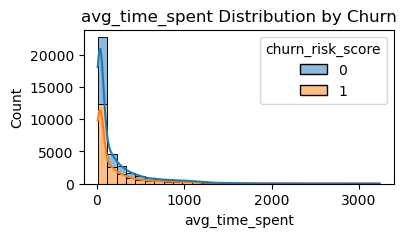

In [31]:
# Plot the graph age vs avg_time_spent
plt.figure(figsize=(4,2))
plt.subplot(1,1,1)
sns.histplot(data=churn_data_2,
             x="avg_time_spent",
             hue="churn_risk_score",
             bins=30,
             kde=True,
             multiple="stack")

plt.title("avg_time_spent Distribution by Churn")
plt.show()


Average time is between 0 and 100 and we have most customers in this area so we have to make stratege to make it good to avoid from churn.

### Avg_transaction_value Data Preprocessing

We have 39.13% null value which is less than 50% so it is better for us to handle this one with mode to avoid from outliers.

0


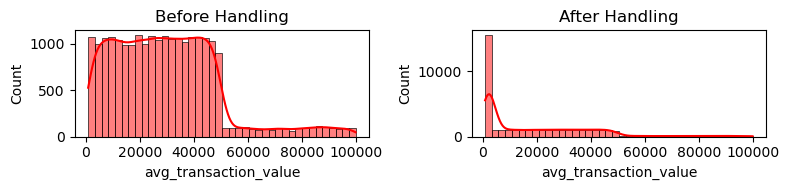

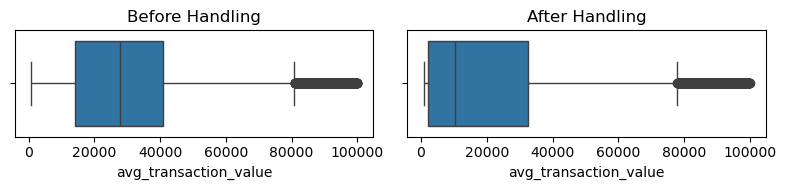

In [32]:
## Handle avg_transaction_value 39.132785
avg_transaction_value_mean=churn_data_2["avg_transaction_value"].mode()[0]
churn_data_2["avg_transaction_value"]=churn_data_2["avg_transaction_value"].fillna(avg_transaction_value_mean)
print(churn_data_2["avg_transaction_value"].isnull().sum())

## Plot the graph
show_graph(churn_data_1["avg_transaction_value"],churn_data_2["avg_transaction_value"])

#### avg_transaction_value vs Churn Risk Analysis

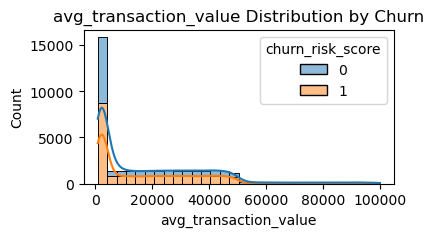

In [33]:
# Plot the graph avg_transaction_value vs churn_risk_score
plt.figure(figsize=(4,2))
plt.subplot(1,1,1)
sns.histplot(data=churn_data_2,
             x="avg_transaction_value",
             hue="churn_risk_score",
             bins=30,
             kde=True,
             multiple="stack")

plt.title("avg_transaction_value Distribution by Churn")
plt.show()


Average transaction money is around 10k and also there we have highest churn risk which make to more oriented to this range of transactions.

### Points_in_wallet Data Preprocessing

As we have 38% null values and we have also outliers so we will use mode for this imputation.

0


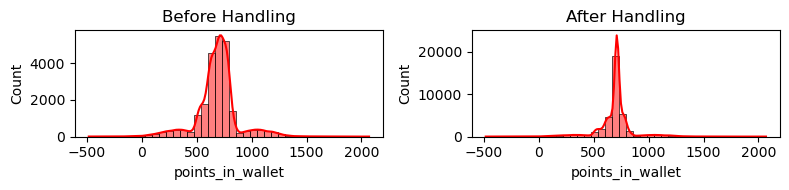

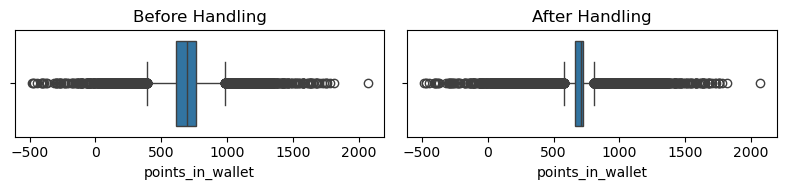

In [34]:
## Handle points_in_wallet 38% Value
points_in_wallets_mean=churn_data_2["points_in_wallet"].mode()[0]
churn_data_2["points_in_wallet"]=churn_data_2["points_in_wallet"].fillna(points_in_wallets_mean)
print(churn_data_2["points_in_wallet"].isnull().sum())

## Plot the graph
show_graph(churn_data_1["points_in_wallet"],churn_data_2["points_in_wallet"])

#### points_in_wallet vs churn Risk Analysis

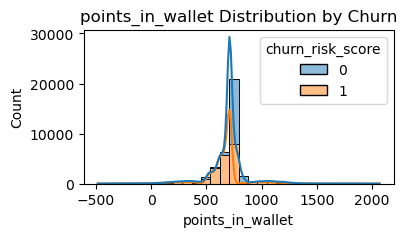

In [35]:
# Plot the graph age vs points_in_wallet
plt.figure(figsize=(4,2))
plt.subplot(1,1,1)
sns.histplot(data=churn_data_2,
             x="points_in_wallet",
             hue="churn_risk_score",
             bins=30,
             kde=True,
             multiple="stack")

plt.title("points_in_wallet Distribution by Churn")
plt.show()


We have most customers that have point around 700 and they have big chances of churn also and for those who have higher number of coins also have risk of churn but due to large no in mid we we need to focus for those ones.

### Avg_frequency_login_days Data Preprocessing

We will less than 50% null values so we will use mode in order to avoid from outlier.

0


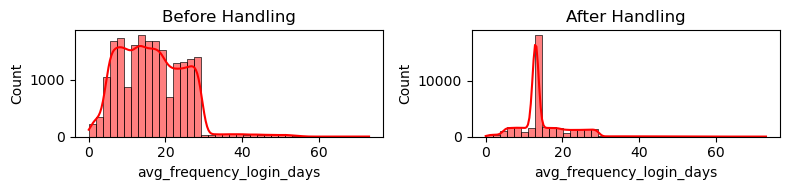

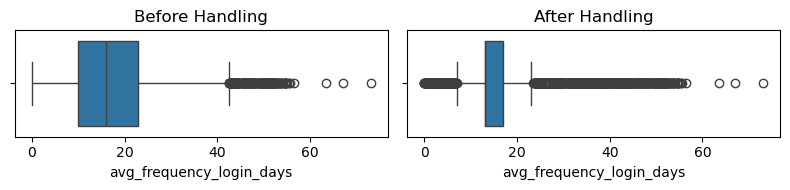

In [36]:
## Handle points_in_wallet 38% Value
avg_frequency_login_days_mean=churn_data_2["avg_frequency_login_days"].mode()[0]
churn_data_2["avg_frequency_login_days"]=churn_data_2["avg_frequency_login_days"].fillna(avg_frequency_login_days_mean)
print(churn_data_2["avg_frequency_login_days"].isnull().sum())

## Plot the graph
show_graph(churn_data_1["avg_frequency_login_days"],churn_data_2["avg_frequency_login_days"])

#### avg_frequency_login_days vs churn Risk Analysis

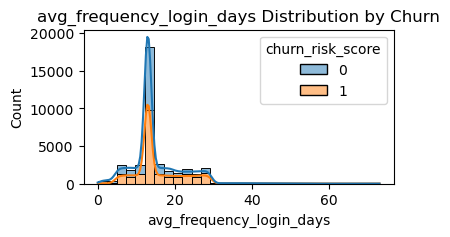

In [37]:
# Plot the graph avg_frequency_login_days vs churn_risk_score
plt.figure(figsize=(4,2))
plt.subplot(1,1,1)
sns.histplot(data=churn_data_2,
             x="avg_frequency_login_days",
             hue="churn_risk_score",
             bins=30,
             kde=True,
             multiple="stack")

plt.title("avg_frequency_login_days Distribution by Churn")
plt.show()


We have mostly equal ratio for customer for average login time but we have most customer at value 16-18 so it is better for us to give more focus on those customers.

## Handle Categorical Features

### Analysis

In [38]:
cat_features.isnull().sum()

gender                          12451
security_no                      7804
region_category                 17342
membership_category             14077
joining_date                     8073
joined_through_referral         16898
referral_id                      8868
preferred_offer_types           10965
medium_of_operation             12250
internet_option                  9194
last_visit_time                  8739
used_special_discount           12844
offer_application_preference     9105
past_complaint                   9422
complaint_status                10475
feedback                         8369
dtype: int64

In [39]:
cat_feat_percent_null=(cat_features.isnull().sum()*100)/cat_features.shape[0]
cat_feat_percent_null

gender                          33.658629
security_no                     21.096453
region_category                 46.880407
membership_category             38.054174
joining_date                    21.823638
joined_through_referral         45.680147
referral_id                     23.972751
preferred_offer_types           29.641544
medium_of_operation             33.115268
internet_option                 24.854022
last_visit_time                 23.624027
used_special_discount           34.721021
offer_application_preference    24.613430
past_complaint                  25.470372
complaint_status                28.316933
feedback                        22.623811
dtype: float64

In [40]:
cat_feat_null_50=cat_feat_percent_null[cat_feat_percent_null>50]
cat_feat_null_50

Series([], dtype: float64)

In [41]:
cat_feat_null_less_50=cat_feat_percent_null[cat_feat_percent_null<=50]
cat_feat_percent_null

gender                          33.658629
security_no                     21.096453
region_category                 46.880407
membership_category             38.054174
joining_date                    21.823638
joined_through_referral         45.680147
referral_id                     23.972751
preferred_offer_types           29.641544
medium_of_operation             33.115268
internet_option                 24.854022
last_visit_time                 23.624027
used_special_discount           34.721021
offer_application_preference    24.613430
past_complaint                  25.470372
complaint_status                28.316933
feedback                        22.623811
dtype: float64

As we dont have any columns having more 50% null value so for all these ones we will handle with mode value.

### Graph Functions

We will make function to visualize the graph of feature and we also make a function to show relatinship between the feature and churn_risk_score.

In [42]:
## plot the graph 
def cat_graph(data,data_new,feature):
    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    sns.countplot(data=data,x=feature,edgecolor="black")
    plt.xticks(rotation=90)
    plt.title("Before Imputation")
    plt.subplot(1,2,2)
    sns.countplot(data=data_new,x=feature,edgecolor="black")
    plt.xticks(rotation=90)
    plt.title("After Imputation")
    plt.tight_layout()
def f_ret_output(data,data_new,feature):
    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    sns.countplot(data=churn_data_1,x=feature,edgecolor="black",hue=data["churn_risk_score"])
    plt.xticks(rotation=90)
    plt.title("Before Imputation")
    plt.subplot(1,2,2)
    sns.countplot(data=churn_data_2,x=feature,edgecolor="black",hue=data_new["churn_risk_score"])
    plt.xticks(rotation=90)
    plt.title("After Imputation")
    plt.tight_layout()

### Gender Data Preprocessing

We have 33.65% null values so we will use mode to handle this one.

gender
F    12299
M    12242
Name: count, dtype: int64
0


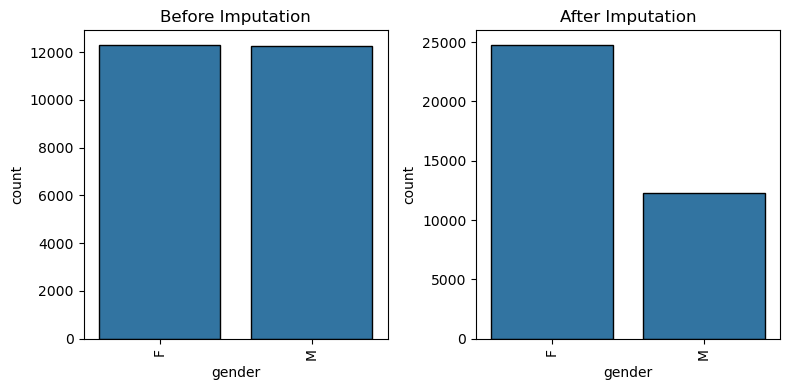

In [43]:
## Handle Gender
print(churn_data_2["gender"].value_counts())
gender_mode=churn_data_2["gender"].mode()[0]
churn_data_2["gender"]=churn_data_2["gender"].fillna(gender_mode)
print(churn_data_2["gender"].isnull().sum())

## Plot the graph
cat_graph(churn_data_1,churn_data_2,"gender")

#### Gender Vs Churn Risk Score Analysis

We will analyse the relationship between the churn score and gender.

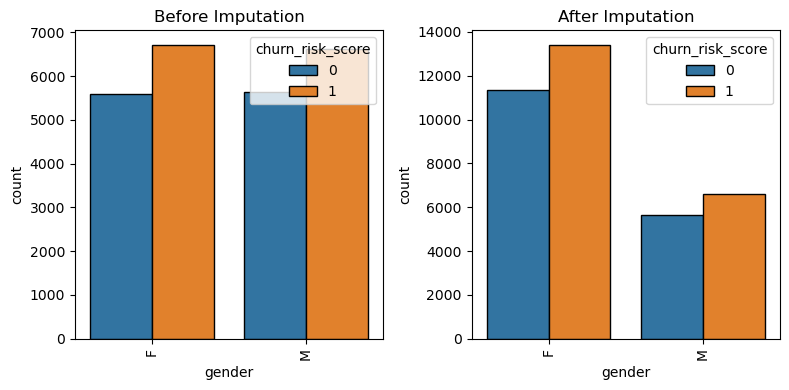

In [44]:
f_ret_output(churn_data_1,churn_data_2,"gender")

Based on our graph gender vs churn_risk_score ,we can conclude that both male and female most probabily equal ratio of churnig,we can say we don't have something that could affect any one gender.

### Region_category Data Preprocessing

We have 46.88% null values which is less than 50% ,so we will handle with mode.

region_category
Town       8796
City       7910
Village    2944
Name: count, dtype: int64
0


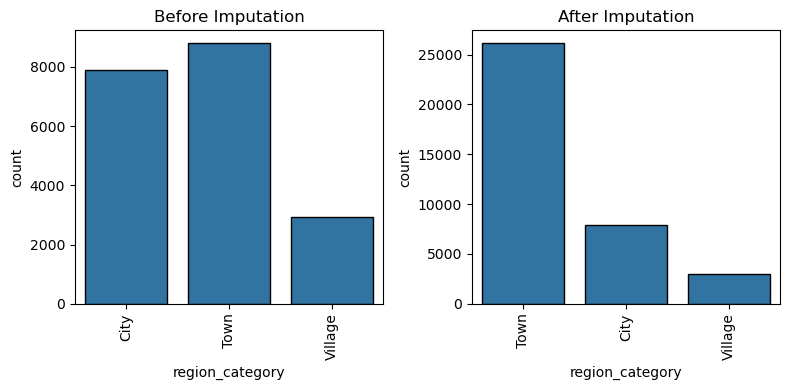

In [45]:
## Handle Region_Category
print(churn_data_2["region_category"].value_counts())
region_category_mode=churn_data_2["region_category"].mode()[0]
churn_data_2["region_category"]=churn_data_2["region_category"].fillna(region_category_mode)
print(churn_data_2["region_category"].isnull().sum())

## Plot the graph
cat_graph(churn_data_1,churn_data_2,"region_category")

#### Region_category vs Churn Risk Analysis

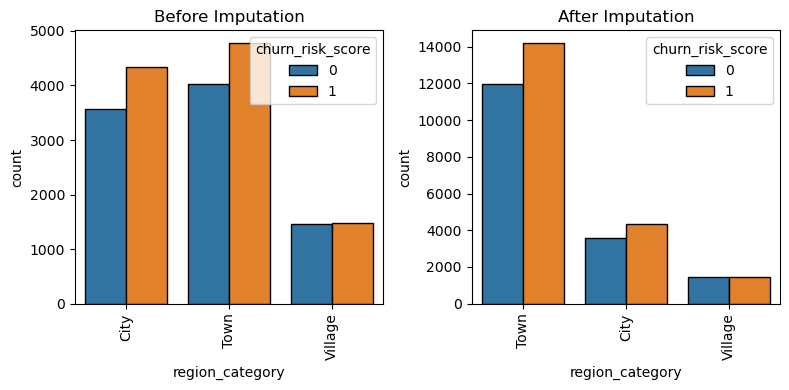

In [46]:
f_ret_output(churn_data_1,churn_data_2,"region_category")

We have equal churn risk on region whether it city or town or village.

### Membership_category Data Preprocessing

As we have 38.05% null values of membership_category so we will impute with mode.

membership_category
Basic Membership       4796
No Membership          4720
Gold Membership        4249
Silver Membership      3694
Premium Membership     2752
Platinum Membership    2704
Name: count, dtype: int64
0


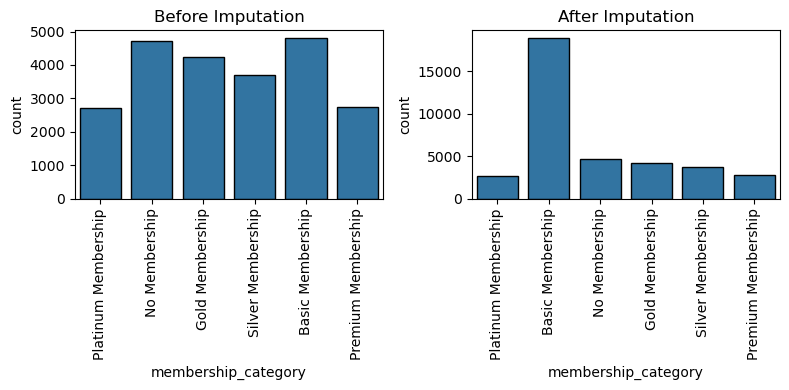

In [47]:
## Handle memebrship_category
print(churn_data_2["membership_category"].value_counts())
memebrship_category_mode=churn_data_2["membership_category"].mode()[0]
churn_data_2["membership_category"]=churn_data_2["membership_category"].fillna(memebrship_category_mode)
print(churn_data_2["membership_category"].isnull().sum())

## Plot the graph
cat_graph(churn_data_1,churn_data_2,"membership_category")

#### Membership_category vs Churn Risk Analysis

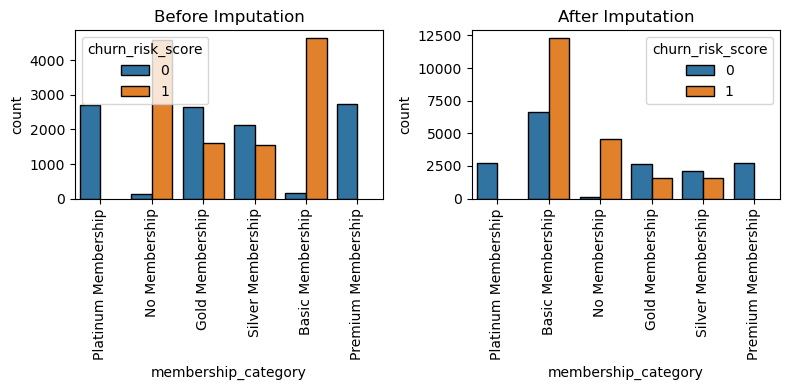

In [48]:
f_ret_output(churn_data_1,churn_data_2,"membership_category")

Here we can see that there those members who are from ***No Membership*** or ***Basic Memberhsip*** have very big chance of churning.and those with any other membership have very less chance of churning.

### Joined_through_referral Data Preprocessing

We have 45.68% null value so we will use mode for handling

joined_through_referral
No     10111
Yes     9983
Name: count, dtype: int64
0


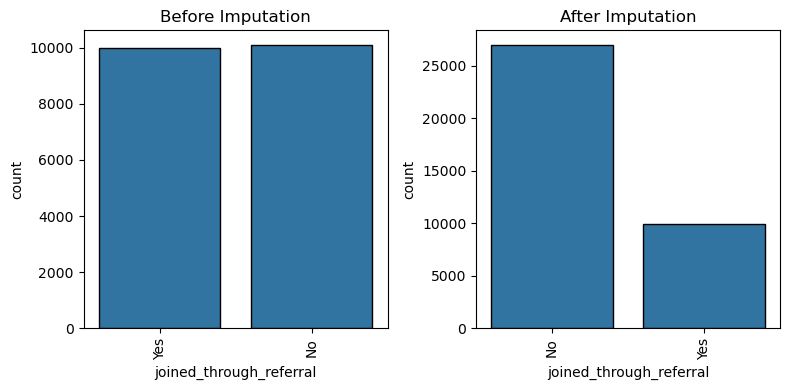

In [49]:
## Handle joined_through_referral
print(churn_data_2["joined_through_referral"].value_counts())
joined_through_referral_mode=churn_data_2["joined_through_referral"].mode()[0]
churn_data_2["joined_through_referral"]=churn_data_2["joined_through_referral"].fillna(joined_through_referral_mode)
print(churn_data_2["joined_through_referral"].isnull().sum())

## Plot the graph
cat_graph(churn_data_1,churn_data_2,"joined_through_referral")

#### Joined_through_referral vs Churn Risk Analysis

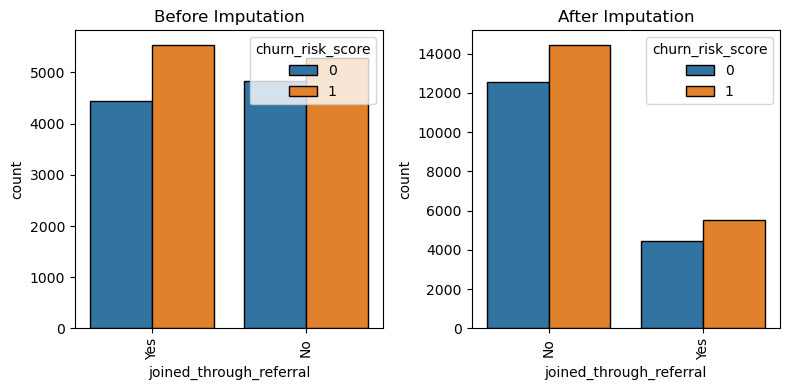

In [50]:
f_ret_output(churn_data_1,churn_data_2,"joined_through_referral")

There we have equal effect on both whether it it through or not but the our negative factors are affecting both on large scale.

### Preferred_offer_types Data Preprocessing

We have 29.64% null values so we will use mode to handle this one.

preferred_offer_types
Credit/Debit Card Offers    8770
Gift Vouchers/Coupons       8723
Without Offers              8534
Name: count, dtype: int64
0


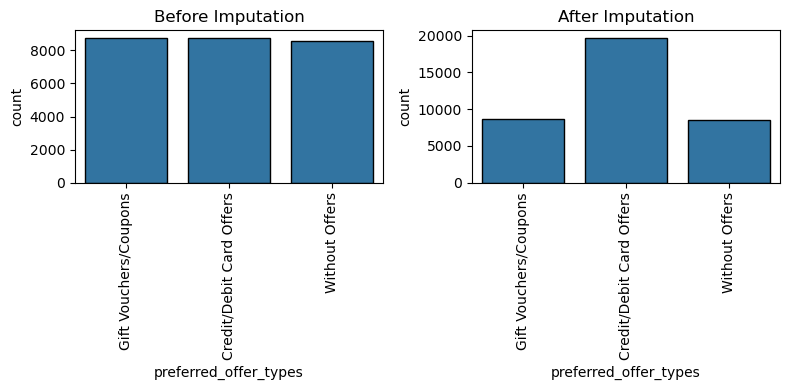

In [51]:
## Handle preferred_offer_types
print(churn_data_2["preferred_offer_types"].value_counts())
preferred_offer_types_mode=churn_data_2["preferred_offer_types"].mode()[0]
churn_data_2["preferred_offer_types"]=churn_data_2["preferred_offer_types"].fillna(preferred_offer_types_mode)
print(churn_data_2["preferred_offer_types"].isnull().sum())

## Plot the graph
cat_graph(churn_data_1,churn_data_2,"preferred_offer_types")

#### Preferred_offer_types vs churn_risk_score Analysis

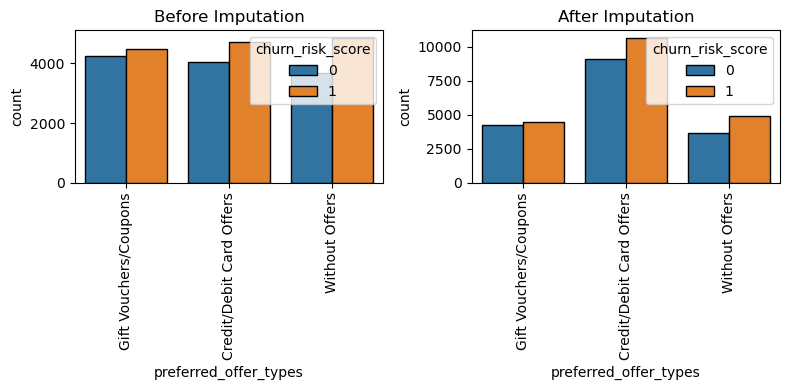

In [52]:
f_ret_output(churn_data_1,churn_data_2,"preferred_offer_types")

Here all of offered types are affected mostly equally.So may be ***preffered offered types*** is not contributing that much to our churning_risk_score.

### Medium_of_operation Data Preprocessing

We have 33% null values and for the handling we will use mode values of the feature.

medium_of_operation
Desktop       10922
Smartphone    10801
Both           3019
Name: count, dtype: int64
0


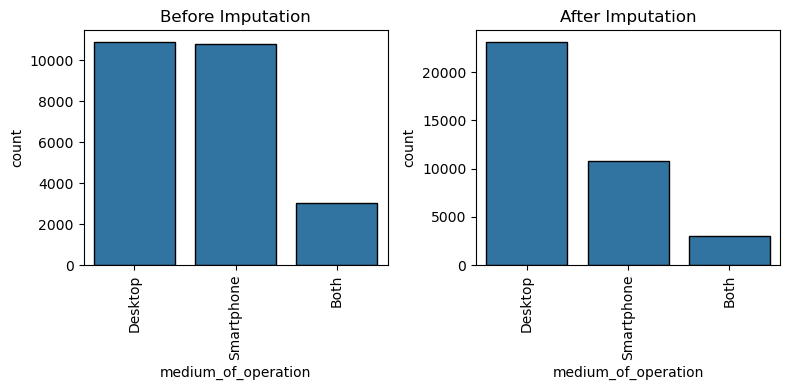

In [53]:
## Handle medium_of_operation
print(churn_data_2["medium_of_operation"].value_counts())
medium_of_operation_mode=churn_data_2["medium_of_operation"].mode()[0]
churn_data_2["medium_of_operation"]=churn_data_2["medium_of_operation"].fillna(medium_of_operation_mode)
print(churn_data_2["medium_of_operation"].isnull().sum())

## Plot the graph
cat_graph(churn_data_1,churn_data_2,"medium_of_operation")

#### Medium_of_operation vs Churn_risk_score Analysis

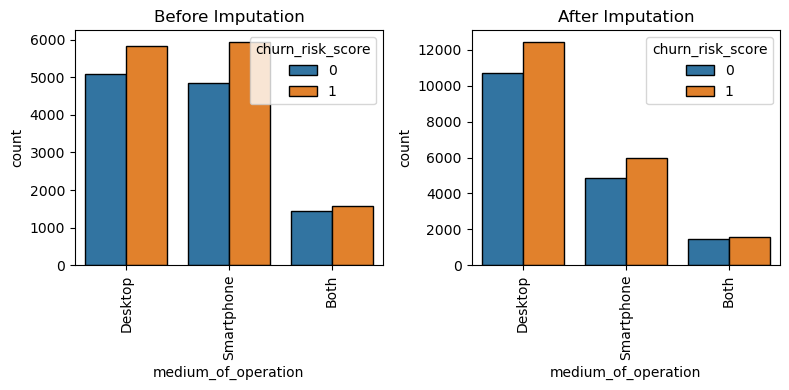

In [54]:
f_ret_output(churn_data_1,churn_data_2,"medium_of_operation")

***Medium of operation*** all categories are equally effected by our company.

### Internet_option DataPreprocessing

We have 24.85% null values so we will use mode for this

internet_option
Wi-Fi          9346
Mobile_Data    9231
Fiber_Optic    9221
Name: count, dtype: int64
0


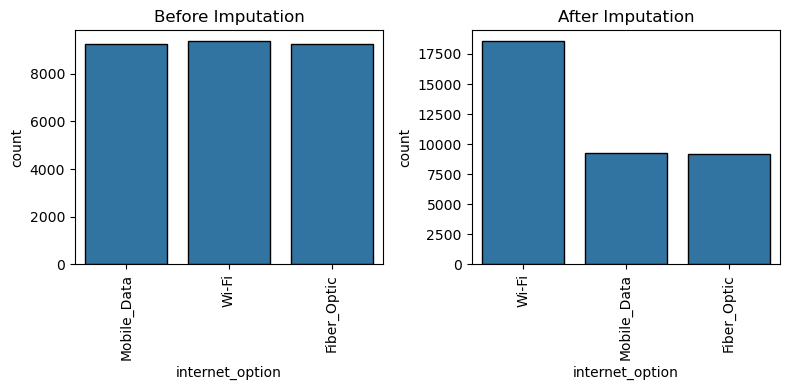

In [55]:
## Handle internet_option
print(churn_data_2["internet_option"].value_counts())
internet_option_mode=churn_data_2["internet_option"].mode()[0]
churn_data_2["internet_option"]=churn_data_2["internet_option"].fillna(internet_option_mode)
print(churn_data_2["internet_option"].isnull().sum())

## Plot the graph
cat_graph(churn_data_1,churn_data_2,"internet_option")

#### Internet_option vs Churn_Risk Analysis

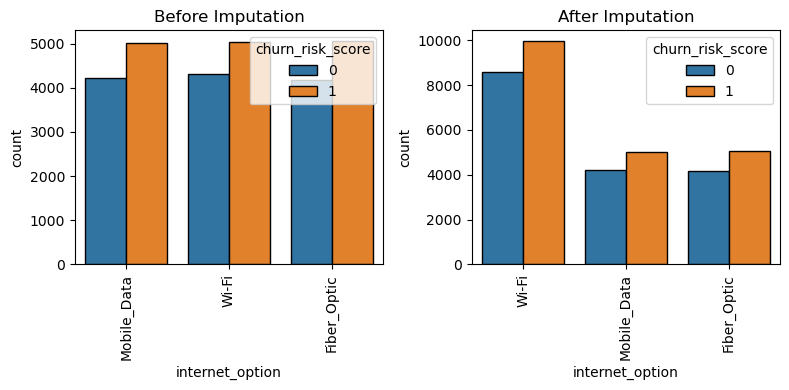

In [56]:
f_ret_output(churn_data_1,churn_data_2,"internet_option")

Internet factors are also equal ,this indicates that we are not having any speciall factors of internet that could affect on specific one.

### Used_special_discount DataPreprocessing

We have 34% null values so we will use mode to handle this one which will balance our model much more.

used_special_discount
Yes    13366
No     10782
Name: count, dtype: int64
0


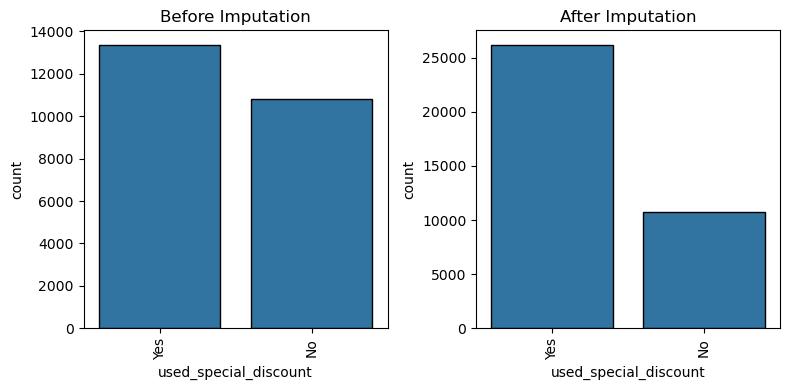

In [57]:
## Handle used_special_discount
print(churn_data_2["used_special_discount"].value_counts())
used_special_discount_mode=churn_data_2["used_special_discount"].mode()[0]
churn_data_2["used_special_discount"]=churn_data_2["used_special_discount"].fillna(used_special_discount_mode)
print(churn_data_2["used_special_discount"].isnull().sum())

## Plot the graph
cat_graph(churn_data_1,churn_data_2,"used_special_discount")

#### Used_special_Discount vs Churn_Risk Analysis

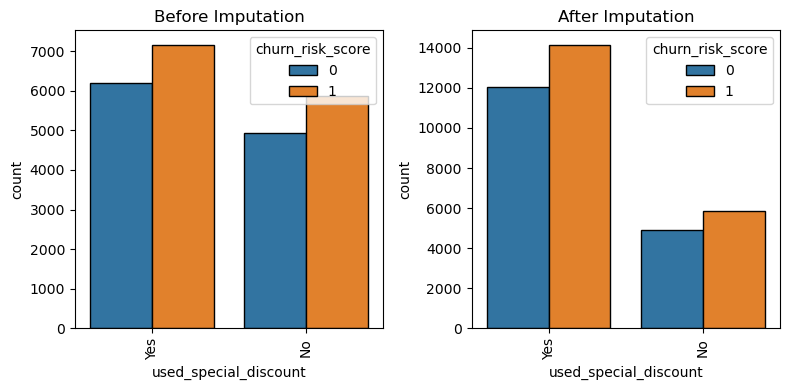

In [58]:
f_ret_output(churn_data_1,churn_data_2,"used_special_discount")

for this feature we have churn ration for both of those ones ,it indicates our special offered used arenot effecting much more .

### Offer_application_preference DataPreprocssing

As we have 24% null values so we will use mode for offer application preference.

offer_application_preference
Yes    15424
No     12463
Name: count, dtype: int64
0


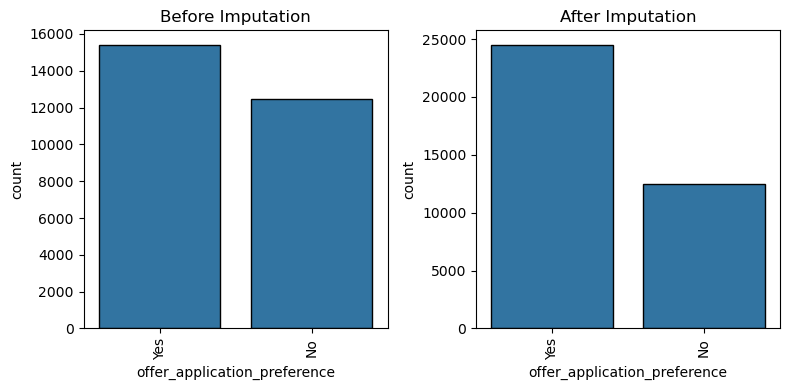

In [59]:
## Handle used_special_discount
print(churn_data_2["offer_application_preference"].value_counts())
offer_application_preference_mode=churn_data_2["offer_application_preference"].mode()[0]
churn_data_2["offer_application_preference"]=churn_data_2["offer_application_preference"].fillna(offer_application_preference_mode)
print(churn_data_2["offer_application_preference"].isnull().sum())

## Plot the graph
cat_graph(churn_data_1,churn_data_2,"offer_application_preference")

#### Offer_application_preference vs Churn Risk Analysis

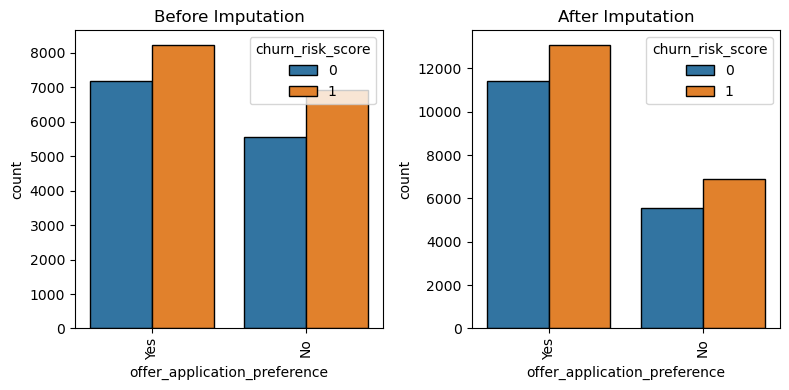

In [60]:
f_ret_output(churn_data_1,churn_data_2,"offer_application_preference")

### Past_complaint DataPreprocessing

We have 25% null values so we will use mode for imputing.

past_complaint
No     13895
Yes    13675
Name: count, dtype: int64
0


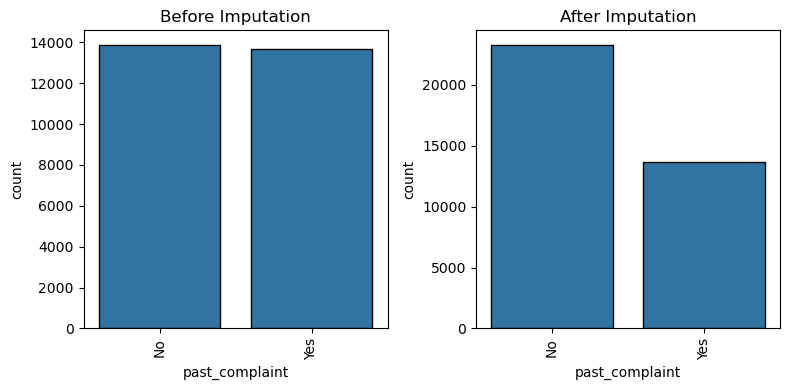

In [61]:
## Handle used_special_discount
print(churn_data_2["past_complaint"].value_counts())
past_complaint_mode=churn_data_2["past_complaint"].mode()[0]
churn_data_2["past_complaint"]=churn_data_2["past_complaint"].fillna(past_complaint_mode)
print(churn_data_2["past_complaint"].isnull().sum())

## Plot the graph
cat_graph(churn_data_1,churn_data_2,"past_complaint")

#### Past_Complaint VS churn_Risk Analysis

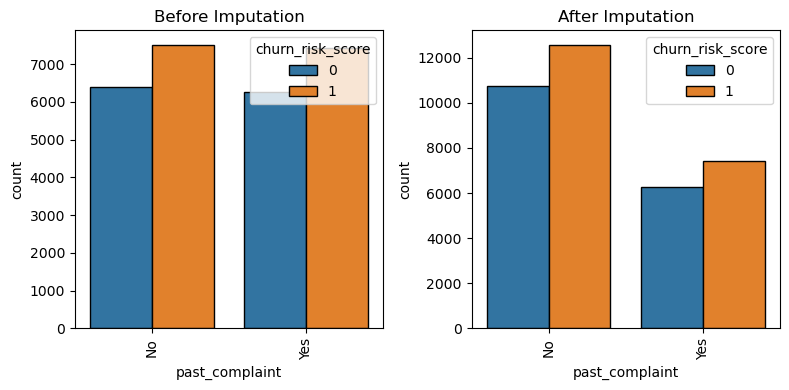

In [62]:
f_ret_output(churn_data_1,churn_data_2,"past_complaint")

if we take the overview of our dataset it does show we have mostly equal customer of having past complaint and not having any complaints

### Complaint_status DataPreprocessing

As we have 28% null values so we will use mode for handling null values.

complaint_status
Not Applicable              13313
Unsolved                     3340
Solved                       3336
Solved in Follow-up          3300
No Information Available     3228
Name: count, dtype: int64
0


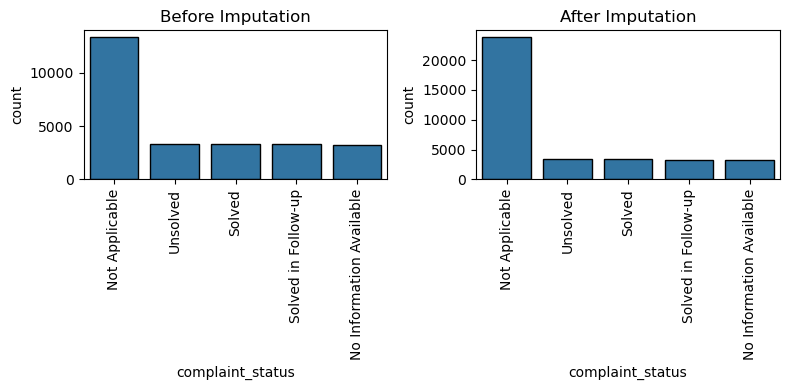

In [63]:
## Handle complaint_status
print(churn_data_2["complaint_status"].value_counts())
complaint_status_mode=churn_data_2["complaint_status"].mode()[0]
churn_data_2["complaint_status"]=churn_data_2["complaint_status"].fillna(complaint_status_mode)
print(churn_data_2["complaint_status"].isnull().sum())

## Plot the graph
cat_graph(churn_data_1,churn_data_2,"complaint_status")

#### Comlaint_status vs churn Risk Analysis

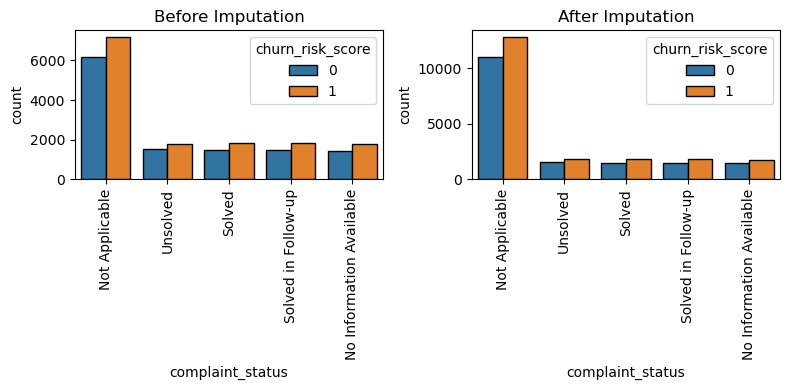

In [64]:
f_ret_output(churn_data_1,churn_data_2,"complaint_status")

Here comes the big change in our dataset we can we see from the graph that those customers who don't have any past complaint have the highest ration of churn ratio which lies in category ***Not Applicable***.

### Feedback Data Preprocessing

Here we have 22.62% null values in this feature and to solve this problem we will use mode for handling the null values.

feedback
Too many ads                4906
Poor Product Quality        4890
Poor Customer Service       4870
No reason specified         4855
Poor Website                4854
Reasonable Price            1086
Products always in Stock    1077
User Friendly Website       1051
Quality Customer Care       1034
Name: count, dtype: int64
0


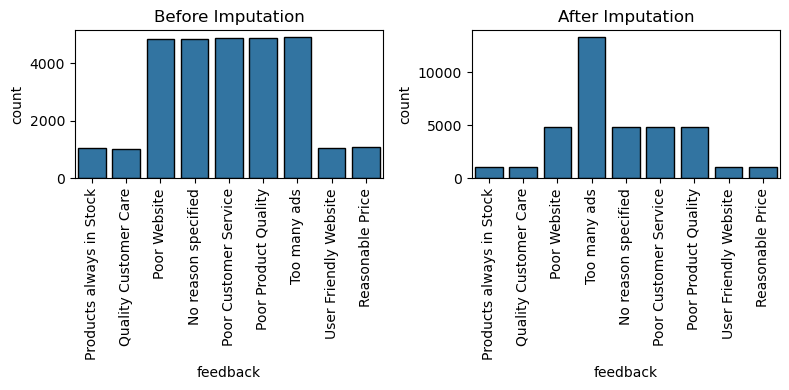

In [65]:
## Handle feedback
print(churn_data_2["feedback"].value_counts())
feedback_mode=churn_data_2["feedback"].mode()[0]
churn_data_2["feedback"]=churn_data_2["feedback"].fillna(feedback_mode)
print(churn_data_2["feedback"].isnull().sum())

## Plot the graph
cat_graph(churn_data_1,churn_data_2,"feedback")

#### Feedback vs Churn_Risk Analysis

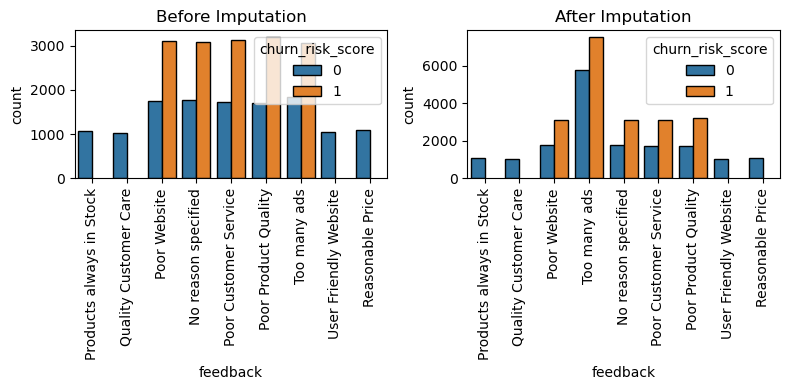

In [66]:
f_ret_output(churn_data_1,churn_data_2,"feedback")

There goes the actual factors as we have feedback ,from which it can be concluded that those people who have problems with ***poor Website***,***no reason specified***,***poor customer service***, ***poor product quality***,***too many ads*** have very high chances of churning which gives the exact insights of reasons.

# Feature Engineering

Based on dataset we will do feature engineering in which we remove those columns that don't have any affect on our model and we will also take care of those columns that have relation to eachother and we will try to combine those ones to take more clear insights.

## Analysis

We have still missing values ,for those ones we will may drop those one or we willl drive other features from those ones.

In [67]:
churn_data_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36992 entries, 0 to 36991
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   age                           36992 non-null  float64
 1   gender                        36992 non-null  object 
 2   security_no                   29188 non-null  object 
 3   region_category               36992 non-null  object 
 4   membership_category           36992 non-null  object 
 5   joining_date                  28919 non-null  object 
 6   joined_through_referral       36992 non-null  object 
 7   referral_id                   28124 non-null  object 
 8   preferred_offer_types         36992 non-null  object 
 9   medium_of_operation           36992 non-null  object 
 10  internet_option               36992 non-null  object 
 11  last_visit_time               28253 non-null  object 
 12  days_since_last_login         36992 non-null  float64
 13  a

In [68]:
churn_data_2.head()

,age,gender,security_no,region_category,membership_category,joining_date,joined_through_referral,referral_id,preferred_offer_types,medium_of_operation,internet_option,last_visit_time,days_since_last_login,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn_risk_score
0,37.060582,F,XW0DQ7H,Town,Platinum Membership,17-08-2017,No,xxxxxxxx,Gift Vouchers/Coupons,Desktop,Wi-Fi,NaN,17.0,31.16,2097.09,17.0,710.69,Yes,Yes,No,Not Applicable,Products always in Stock,0
1,32.000000,F,5K0N3X1,City,Basic Membership,28-08-2017,No,CID21329,Gift Vouchers/Coupons,Desktop,Mobile_Data,12:38:13,16.0,31.16,2097.09,10.0,710.69,Yes,No,Yes,Not Applicable,Quality Customer Care,0
2,44.000000,F,1F2TCL3,Town,Basic Membership,11-11-2016,Yes,CID12313,Credit/Debit Card Offers,Desktop,Wi-Fi,22:53:21,14.0,31.16,2097.09,22.0,710.69,No,Yes,No,Not Applicable,Poor Website,1
3,37.000000,M,VJGJ33N,City,No Membership,29-10-2016,Yes,CID3793,Credit/Debit Card Offers,Desktop,Mobile_Data,15:57:50,11.0,53.27,25239.56,6.0,567.66,Yes,Yes,Yes,Unsolved,Too many ads,1
4,37.060582,F,SVZXCWB,Town,Basic Membership,12-09-2017,No,xxxxxxxx,Credit/Debit Card Offers,Smartphone,Wi-Fi,15:46:44,20.0,113.13,24483.66,16.0,710.69,Yes,Yes,No,Solved,Poor Website,1


## Feature Selection and Column Removal

As columns ***Security_no***,***last_visit_time*** and ***refereral_id*** are the columns are given unique to colums to track the record so these columns cannot affect our prediction that why we need to remove these columns

In [69]:
churn_data_2=churn_data_2.drop(["security_no","referral_id","last_visit_time"],axis=1)

## Feature Creation

### Year_joining,Active_days,Active_years Features Creaction

As we know that our joining date is given in object form so we will change it to date form and then we will extract ***year*** from it because we will use year for our prediction, from our given joining_date we will also make ***active_days*** and ***active_years***

In [70]:
churn_data_2["joining_date"]=pd.to_datetime(churn_data_2["joining_date"])
churn_data_2["year_joining"]=churn_data_2["joining_date"].dt.year
churn_data_2["joining_date"] = pd.to_datetime(churn_data_2["joining_date"])

churn_data_2["active_days"] = (pd.Timestamp.now() - churn_data_2["joining_date"]).dt.days

churn_data_2["active_years"] = churn_data_2["active_days"] / 365

C:\Users\HP\AppData\Local\Temp\ipykernel_19756\1975585332.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  churn_data_2["joining_date"]=pd.to_datetime(churn_data_2["joining_date"])


#### The year_Joining Column DataPreprocessing And Graph Analysis

As 21% are null values so we will use mode to replace.

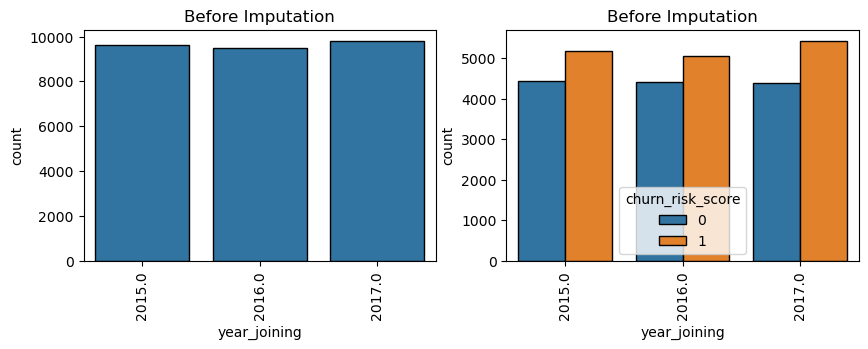

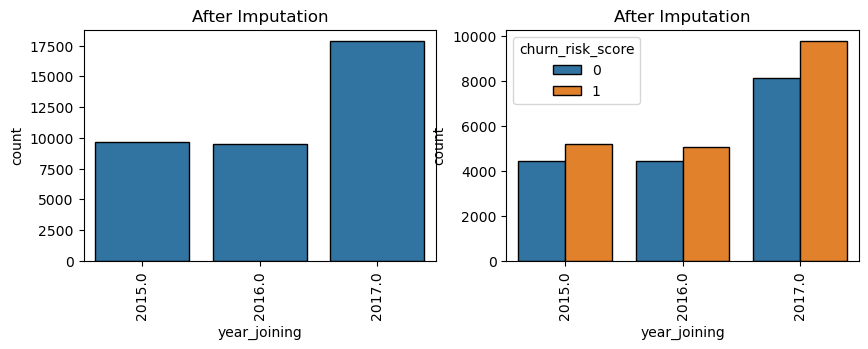

In [71]:
# Function for graph
def before_imputation(data,feature):
    plt.figure(figsize=(10,3))
    plt.subplot(1,2,1)
    sns.countplot(data=data,x=feature,edgecolor="black")
    plt.xticks(rotation=90)
    plt.title("Before Imputation")
    plt.subplot(1,2,2)
    sns.countplot(data=churn_data_2,x=feature,edgecolor="black",hue=data["churn_risk_score"])
    plt.xticks(rotation=90)
    plt.title("Before Imputation")
def after_imputation(data,feature):
    plt.figure(figsize=(10,3))
    plt.subplot(1,2,1)
    sns.countplot(data=data,x=feature,edgecolor="black")
    plt.xticks(rotation=90)
    plt.title("After Imputation")
    plt.subplot(1,2,2)
    sns.countplot(data=churn_data_2,x=feature,edgecolor="black",hue=data["churn_risk_score"])
    plt.xticks(rotation=90)
    plt.title("After Imputation")
# Grpah Before Imputation 
before_imputation(churn_data_2,"year_joining")
# Handle The Year 
year_mode=churn_data_2["year_joining"].mode()[0]
churn_data_2["year_joining"]=churn_data_2["year_joining"].fillna(year_mode)
churn_data_2["year_joining"].isnull().sum()
#Grpah After Imputation
after_imputation(churn_data_2,"year_joining")

#### Active_years DataPreprocessing and Graph Analysis

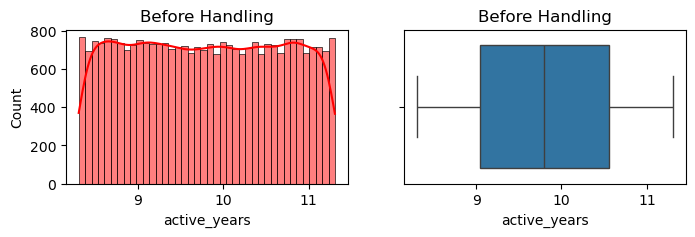

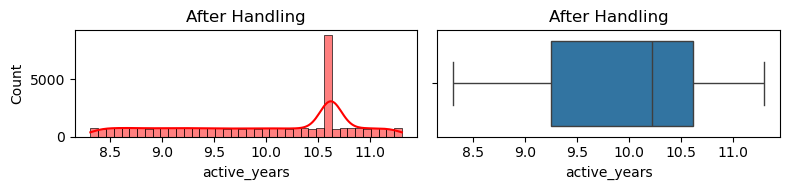

In [72]:
def before_imputation(data):
    plt.figure(figsize=(8,2))
    plt.subplot(1,2,1)
    sns.histplot(data=data,bins=40,color="red",kde=True)
    plt.title("Before Handling")
    plt.subplot(1,2,2)
    sns.boxplot(x=data)
    plt.title("Before Handling")
    plt.show()
def after_imputation(data):
    plt.figure(figsize=(8,2))
    plt.subplot(1,2,1)
    sns.histplot(data=data,bins=40,color="red",kde=True)
    plt.title("After Handling")
    plt.tight_layout()
    plt.subplot(1,2,2)
    sns.boxplot(x=data)
    plt.title("After Handling")
    plt.tight_layout()
# Graph before Impuation
before_imputation(churn_data_2["active_years"])
# Handle The Year 
year_mode=churn_data_2["active_years"].mode()[0]
churn_data_2["active_years"]=churn_data_2["active_years"].fillna(year_mode)
churn_data_2["active_years"].isnull().sum()
#Graph after Imputation
after_imputation(churn_data_2["active_years"])

#### Active_days DataPreprocessing And Graph Analysis

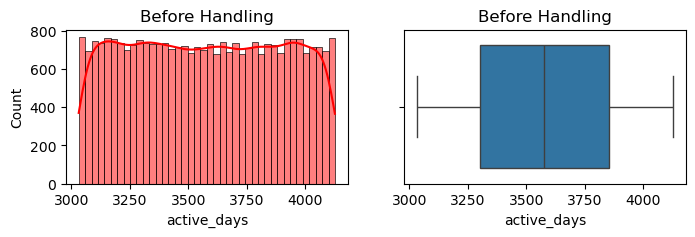

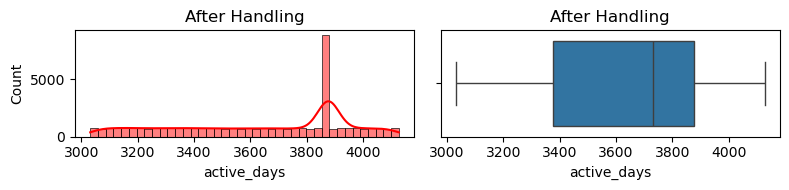

In [73]:
def before_imputation(data):
    plt.figure(figsize=(8,2))
    plt.subplot(1,2,1)
    sns.histplot(data=data,bins=40,color="red",kde=True)
    plt.title("Before Handling")
    plt.subplot(1,2,2)
    sns.boxplot(x=data)
    plt.title("Before Handling")
    plt.show()
def after_imputation(data):
    plt.figure(figsize=(8,2))
    plt.subplot(1,2,1)
    sns.histplot(data=data,bins=40,color="red",kde=True)
    plt.title("After Handling")
    plt.tight_layout()
    plt.subplot(1,2,2)
    sns.boxplot(x=data)
    plt.title("After Handling")
    plt.tight_layout()
# Graph before Impuation
before_imputation(churn_data_2["active_days"])
# Handle The Year 
year_mode=churn_data_2["active_days"].mode()[0]
churn_data_2["active_days"]=churn_data_2["active_days"].fillna(year_mode)
churn_data_2["active_days"].isnull().sum()
#Graph after Imputation
after_imputation(churn_data_2["active_days"])

### Past_complaint_status Feature Creation

Based on our given data we will combine the feature past complaint and its complaint status to make a new feature to check how it is solved or not.

In [74]:
churn_data_2["past_complaint_status"]=churn_data_2["past_complaint"]+churn_data_2["complaint_status"]
churn_data_2["past_complaint_status"].value_counts()

past_complaint_status
NoNot Applicable               19945
YesNot Applicable               3843
YesUnsolved                     2491
YesSolved in Follow-up          2473
YesSolved                       2459
YesNo Information Available     2409
NoSolved                         877
NoUnsolved                       849
NoSolved in Follow-up            827
NoNo Information Available       819
Name: count, dtype: int64

From our combinned columns we have some invalid columns which we will make them null and will replace with nan.

In [75]:
churn_data_2["past_complaint_status"]=churn_data_2["past_complaint_status"].replace("NoUnsolved",np.nan)
churn_data_2["past_complaint_status"]=churn_data_2["past_complaint_status"].replace("NoSolved in Follow-up",np.nan)

In [76]:
churn_data_2["past_complaint_status"]=churn_data_2["past_complaint_status"].fillna(churn_data_2["past_complaint_status"].mode()[0])

### avg_time_on_day creation

As we have avg_time_spend and avg_frequency_login_days so we can combine these two columns to check how much customer spend their time on website for one time when they come across to it.

In [77]:
churn_data_2["avg_time_on_day"]=churn_data_2["avg_time_spent"]*churn_data_2["avg_frequency_login_days"]

## Feature Dropping

We have many columns from which we have made new feature so from our old dataset we will drop those columns that we don't need for our prediction.

In [78]:
churn_data_2=churn_data_2.drop("joining_date",axis=1)
churn_data_2=churn_data_2.drop(columns=["avg_time_spent","avg_frequency_login_days"])

## Heatmap Analysis

In [79]:
churn_data_2.isnull().sum()

age                             0
gender                          0
region_category                 0
membership_category             0
joined_through_referral         0
preferred_offer_types           0
medium_of_operation             0
internet_option                 0
days_since_last_login           0
avg_transaction_value           0
points_in_wallet                0
used_special_discount           0
offer_application_preference    0
past_complaint                  0
complaint_status                0
feedback                        0
churn_risk_score                0
year_joining                    0
active_days                     0
active_years                    0
past_complaint_status           0
avg_time_on_day                 0
dtype: int64

<Axes: >

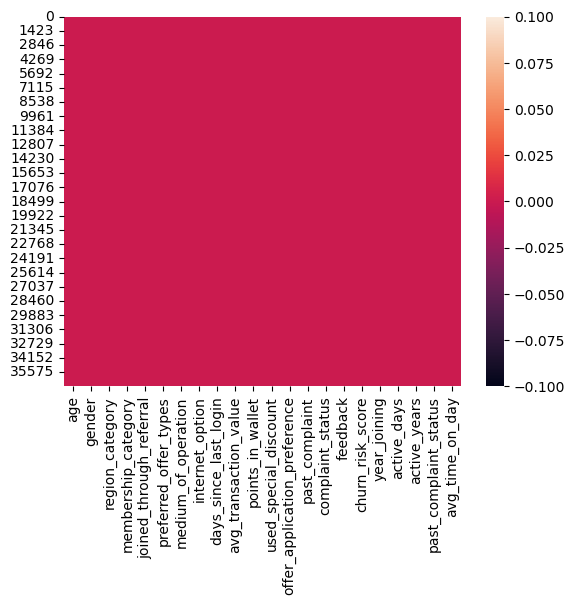

In [80]:
sns.heatmap(data=churn_data_2.isnull())

## Encoding One Hot Encoder

In [81]:
churn_data_encoding=churn_data_2.select_dtypes("object")
cols=["gender","region_category","membership_category","joined_through_referral","preferred_offer_types",
"medium_of_operation","internet_option","used_special_discount","offer_application_preference","past_complaint","complaint_status","feedback","past_complaint_status"]

In [82]:
ohe=OneHotEncoder(drop="first",handle_unknown="ignore",sparse_output=False)
encoded=ohe.fit_transform(churn_data_2[cols])
encoded_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(cols),index=churn_data_2.index)
churn_data_encoded=pd.concat([churn_data_2.drop(columns=cols),encoded_df],axis=1)

In [83]:
print("Before The One Hot encoder: ",churn_data_2.shape)
print("After The One Hot Encoder: ",churn_data_encoded.shape)

Before The One Hot encoder:  (36992, 22)
After The One Hot Encoder:  (36992, 46)


In [84]:
churn_data_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36992 entries, 0 to 36991
Data columns (total 46 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   age                                                36992 non-null  float64
 1   days_since_last_login                              36992 non-null  float64
 2   avg_transaction_value                              36992 non-null  float64
 3   points_in_wallet                                   36992 non-null  float64
 4   churn_risk_score                                   36992 non-null  int64  
 5   year_joining                                       36992 non-null  float64
 6   active_days                                        36992 non-null  float64
 7   active_years                                       36992 non-null  float64
 8   avg_time_on_day                                    36992 non-null  float64
 9   gender

In [85]:
churn_data_encoded.head()

,age,days_since_last_login,avg_transaction_value,points_in_wallet,churn_risk_score,year_joining,active_days,active_years,avg_time_on_day,gender_M,region_category_Town,region_category_Village,membership_category_Gold Membership,membership_category_No Membership,membership_category_Platinum Membership,membership_category_Premium Membership,membership_category_Silver Membership,joined_through_referral_Yes,preferred_offer_types_Gift Vouchers/Coupons,preferred_offer_types_Without Offers,medium_of_operation_Desktop,medium_of_operation_Smartphone,internet_option_Mobile_Data,internet_option_Wi-Fi,used_special_discount_Yes,offer_application_preference_Yes,past_complaint_Yes,complaint_status_Not Applicable,complaint_status_Solved,complaint_status_Solved in Follow-up,complaint_status_Unsolved,feedback_Poor Customer Service,feedback_Poor Product Quality,feedback_Poor Website,feedback_Products always in Stock,feedback_Quality Customer Care,feedback_Reasonable Price,feedback_Too many ads,feedback_User Friendly Website,past_complaint_status_NoNot Applicable,past_complaint_status_NoSolved,past_complaint_status_YesNo Information Available,past_complaint_status_YesNot Applicable,past_complaint_status_YesSolved,past_complaint_status_YesSolved in Follow-up,past_complaint_status_YesUnsolved
0,37.060582,17.0,2097.09,710.69,0,2017.0,3168.0,8.679452,529.72,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,32.000000,16.0,2097.09,710.69,0,2017.0,3157.0,8.649315,311.60,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,44.000000,14.0,2097.09,710.69,1,2016.0,3447.0,9.443836,685.52,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,37.000000,11.0,25239.56,567.66,1,2016.0,3460.0,9.479452,319.62,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,37.060582,20.0,24483.66,710.69,1,2017.0,3142.0,8.608219,1810.08,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [86]:
churn_data_encoded

,age,days_since_last_login,avg_transaction_value,points_in_wallet,churn_risk_score,year_joining,active_days,active_years,avg_time_on_day,gender_M,region_category_Town,region_category_Village,membership_category_Gold Membership,membership_category_No Membership,membership_category_Platinum Membership,membership_category_Premium Membership,membership_category_Silver Membership,joined_through_referral_Yes,preferred_offer_types_Gift Vouchers/Coupons,preferred_offer_types_Without Offers,medium_of_operation_Desktop,medium_of_operation_Smartphone,internet_option_Mobile_Data,internet_option_Wi-Fi,used_special_discount_Yes,offer_application_preference_Yes,past_complaint_Yes,complaint_status_Not Applicable,complaint_status_Solved,complaint_status_Solved in Follow-up,complaint_status_Unsolved,feedback_Poor Customer Service,feedback_Poor Product Quality,feedback_Poor Website,feedback_Products always in Stock,feedback_Quality Customer Care,feedback_Reasonable Price,feedback_Too many ads,feedback_User Friendly Website,past_complaint_status_NoNot Applicable,past_complaint_status_NoSolved,past_complaint_status_YesNo Information Available,past_complaint_status_YesNot Applicable,past_complaint_status_YesSolved,past_complaint_status_YesSolved in Follow-up,past_complaint_status_YesUnsolved
0,37.060582,17.00000,2097.09,710.690000,0,2017.0,3168.0,8.679452,529.720000,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,32.000000,16.00000,2097.09,710.690000,0,2017.0,3157.0,8.649315,311.600000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,44.000000,14.00000,2097.09,710.690000,1,2016.0,3447.0,9.443836,685.520000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,37.000000,11.00000,25239.56,567.660000,1,2016.0,3460.0,9.479452,319.620000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,37.060582,20.00000,24483.66,710.690000,1,2017.0,3142.0,8.608219,1810.080000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36987,37.060582,12.77086,27277.68,710.690000,1,2017.0,3133.0,8.583562,8458.875861,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
36988,37.060582,12.77086,2097.09,527.990000,1,2016.0,3584.0,9.819178,17867.455782,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
36989,23.000000,12.00000,38127.56,680.470000,1,2017.0,3877.0,10.621918,2014.220000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
36990,53.000000,15.00000,2378.86,197.264414,0,2017.0,3231.0,8.852055,623.200000,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


# Feature Scaling

## Normaliztion

We have much higher value of avg_trnasaction value and points_in_wallets,avg_time_on_day as compared to our other data so we will normalize it make it valid for other columns also .

In [87]:
scaler=MinMaxScaler()
churn_data_encoded["avg_transaction_value_norm"]=scaler.fit_transform(churn_data_encoded[["avg_transaction_value"]])
churn_data_encoded["points_in_wallets_norm"]=scaler.fit_transform(churn_data_encoded[["points_in_wallet"]])
churn_data_encoded["avg_time_on_day_norm"]=scaler.fit_transform(churn_data_encoded[["avg_time_on_day"]])

## Drop UnNormalized Features

As we have made some features normalized to meet the equivalance with other features ,so we will drop unnormalized features.

In [88]:
churn_data_encoded=churn_data_encoded.drop("avg_transaction_value",axis=1)
churn_data_encoded=churn_data_encoded.drop("points_in_wallet",axis=1)
churn_data_encoded=churn_data_encoded.drop("avg_time_on_day",axis=1)

In [89]:
churn_data_encoded.head()

,age,days_since_last_login,churn_risk_score,year_joining,active_days,active_years,gender_M,region_category_Town,region_category_Village,membership_category_Gold Membership,membership_category_No Membership,membership_category_Platinum Membership,membership_category_Premium Membership,membership_category_Silver Membership,joined_through_referral_Yes,preferred_offer_types_Gift Vouchers/Coupons,preferred_offer_types_Without Offers,medium_of_operation_Desktop,medium_of_operation_Smartphone,internet_option_Mobile_Data,internet_option_Wi-Fi,used_special_discount_Yes,offer_application_preference_Yes,past_complaint_Yes,complaint_status_Not Applicable,complaint_status_Solved,complaint_status_Solved in Follow-up,complaint_status_Unsolved,feedback_Poor Customer Service,feedback_Poor Product Quality,feedback_Poor Website,feedback_Products always in Stock,feedback_Quality Customer Care,feedback_Reasonable Price,feedback_Too many ads,feedback_User Friendly Website,past_complaint_status_NoNot Applicable,past_complaint_status_NoSolved,past_complaint_status_YesNo Information Available,past_complaint_status_YesNot Applicable,past_complaint_status_YesSolved,past_complaint_status_YesSolved in Follow-up,past_complaint_status_YesUnsolved,avg_transaction_value_norm,points_in_wallets_norm,avg_time_on_day_norm
0,37.060582,17.0,0,2017.0,3168.0,8.679452,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.013044,0.467913,0.005362
1,32.000000,16.0,0,2017.0,3157.0,8.649315,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.013044,0.467913,0.003153
2,44.000000,14.0,1,2016.0,3447.0,9.443836,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.013044,0.467913,0.006940
3,37.000000,11.0,1,2016.0,3460.0,9.479452,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.246547,0.411887,0.003235
4,37.060582,20.0,1,2017.0,3142.0,8.608219,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.238920,0.467913,0.018329


# Correlation Analysis

In [90]:
churn_data_encoded.head()

,age,days_since_last_login,churn_risk_score,year_joining,active_days,active_years,gender_M,region_category_Town,region_category_Village,membership_category_Gold Membership,membership_category_No Membership,membership_category_Platinum Membership,membership_category_Premium Membership,membership_category_Silver Membership,joined_through_referral_Yes,preferred_offer_types_Gift Vouchers/Coupons,preferred_offer_types_Without Offers,medium_of_operation_Desktop,medium_of_operation_Smartphone,internet_option_Mobile_Data,internet_option_Wi-Fi,used_special_discount_Yes,offer_application_preference_Yes,past_complaint_Yes,complaint_status_Not Applicable,complaint_status_Solved,complaint_status_Solved in Follow-up,complaint_status_Unsolved,feedback_Poor Customer Service,feedback_Poor Product Quality,feedback_Poor Website,feedback_Products always in Stock,feedback_Quality Customer Care,feedback_Reasonable Price,feedback_Too many ads,feedback_User Friendly Website,past_complaint_status_NoNot Applicable,past_complaint_status_NoSolved,past_complaint_status_YesNo Information Available,past_complaint_status_YesNot Applicable,past_complaint_status_YesSolved,past_complaint_status_YesSolved in Follow-up,past_complaint_status_YesUnsolved,avg_transaction_value_norm,points_in_wallets_norm,avg_time_on_day_norm
0,37.060582,17.0,0,2017.0,3168.0,8.679452,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.013044,0.467913,0.005362
1,32.000000,16.0,0,2017.0,3157.0,8.649315,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.013044,0.467913,0.003153
2,44.000000,14.0,1,2016.0,3447.0,9.443836,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.013044,0.467913,0.006940
3,37.000000,11.0,1,2016.0,3460.0,9.479452,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.246547,0.411887,0.003235
4,37.060582,20.0,1,2017.0,3142.0,8.608219,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.238920,0.467913,0.018329


In [91]:
churn_data_encoded.describe()

,age,days_since_last_login,churn_risk_score,year_joining,active_days,active_years,gender_M,region_category_Town,region_category_Village,membership_category_Gold Membership,membership_category_No Membership,membership_category_Platinum Membership,membership_category_Premium Membership,membership_category_Silver Membership,joined_through_referral_Yes,preferred_offer_types_Gift Vouchers/Coupons,preferred_offer_types_Without Offers,medium_of_operation_Desktop,medium_of_operation_Smartphone,internet_option_Mobile_Data,internet_option_Wi-Fi,used_special_discount_Yes,offer_application_preference_Yes,past_complaint_Yes,complaint_status_Not Applicable,complaint_status_Solved,complaint_status_Solved in Follow-up,complaint_status_Unsolved,feedback_Poor Customer Service,feedback_Poor Product Quality,feedback_Poor Website,feedback_Products always in Stock,feedback_Quality Customer Care,feedback_Reasonable Price,feedback_Too many ads,feedback_User Friendly Website,past_complaint_status_NoNot Applicable,past_complaint_status_NoSolved,past_complaint_status_YesNo Information Available,past_complaint_status_YesNot Applicable,past_complaint_status_YesSolved,past_complaint_status_YesSolved in Follow-up,past_complaint_status_YesUnsolved,avg_transaction_value_norm,points_in_wallets_norm,avg_time_on_day_norm
count,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.00000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000
mean,37.060582,12.770860,0.540982,2016.222913,3642.504893,9.979465,0.330936,0.706585,0.079585,0.114863,0.127595,0.073097,0.074394,0.099859,0.269869,0.235808,0.230699,0.626406,0.291982,0.249540,0.501189,0.708532,0.663089,0.369675,0.643058,0.090182,0.089208,0.09029,0.131650,0.132191,0.131218,0.029114,0.027952,0.029358,0.358861,0.028412,0.584478,0.023708,0.065122,0.103887,0.066474,0.066852,0.067339,0.180883,0.461862,0.030550
std,13.514239,4.596565,0.498324,0.833166,307.037447,0.841198,0.470557,0.455333,0.270653,0.318860,0.333643,0.260299,0.262415,0.299817,0.443898,0.424508,0.421286,0.483764,0.454680,0.432753,0.500005,0.454445,0.472660,0.482723,0.479104,0.286446,0.285048,0.28660,0.338115,0.338703,0.337643,0.168129,0.164838,0.168809,0.479673,0.166148,0.492819,0.152139,0.246745,0.305118,0.249112,0.249769,0.250611,0.204684,0.060618,0.051766
min,10.000000,1.000000,0.000000,2015.000000,3032.000000,8.306849,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,29.000000,11.000000,0.000000,2015.000000,3376.000000,9.249315,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.013044,0.448902,0.004100
50%,37.060582,12.770860,1.000000,2016.000000,3731.000000,10.221918,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000

<Axes: >

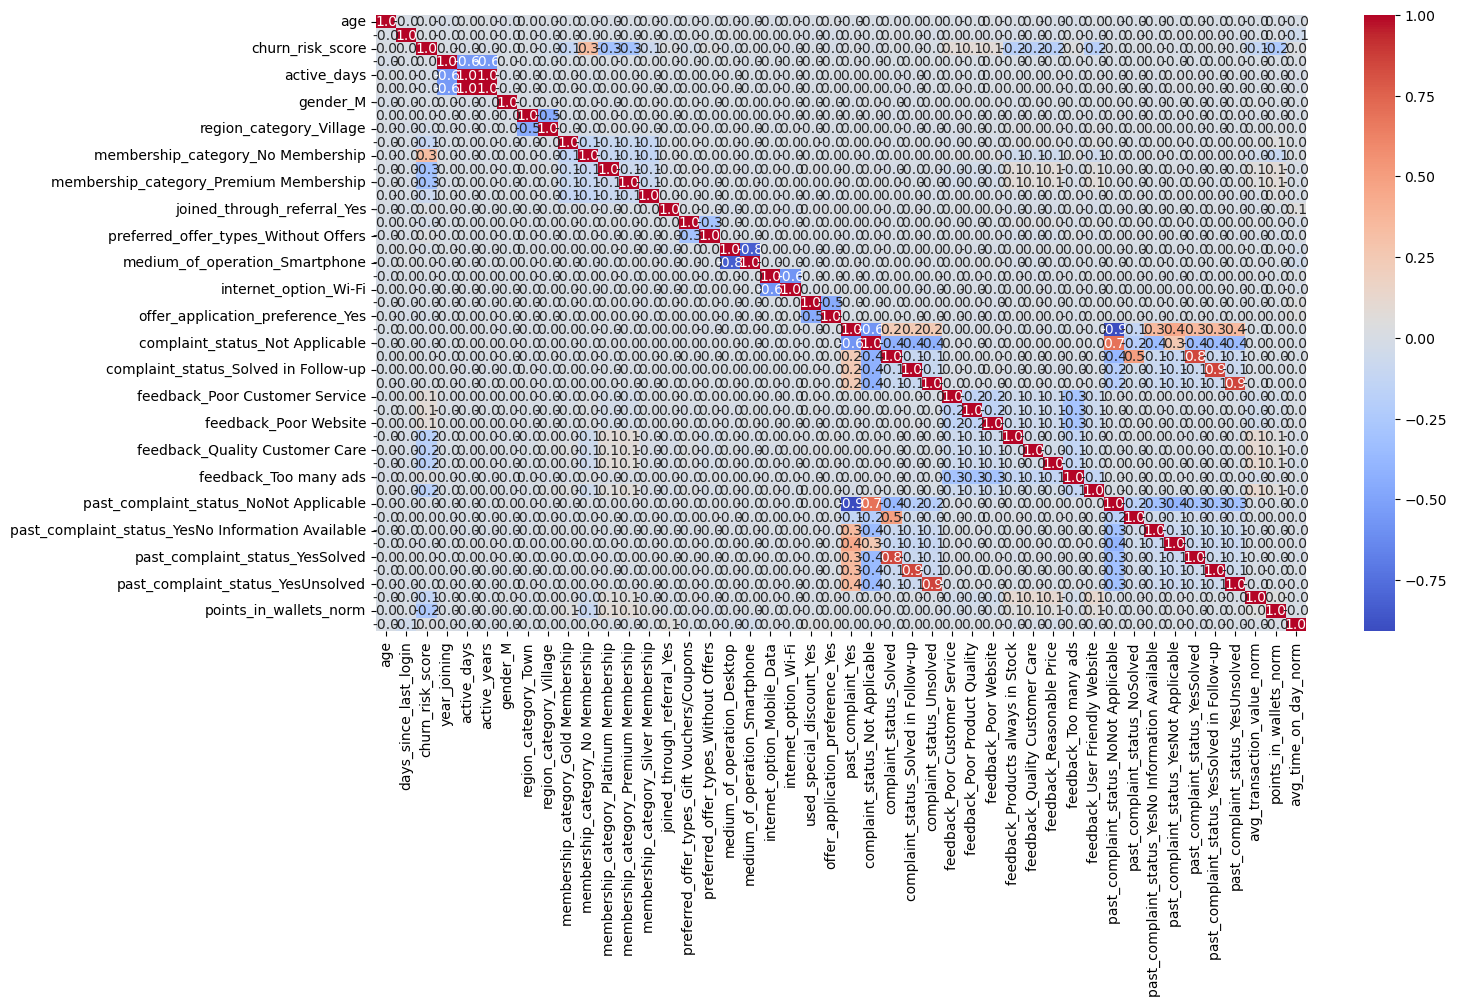

In [92]:
num_cols=churn_data_encoded.select_dtypes(include="number")
corr_matrix=num_cols.corr()
plt.figure(figsize=(15,8))
sns.heatmap(corr_matrix,
            annot=True,
            fmt="0.1f",
            cmap="coolwarm")

# Dataset Spliting and Train Test Spliting

We will split our dataset into features and out output and We will also divide our data into train and test split...

In [93]:
x_data=churn_data_encoded.drop("churn_risk_score",axis=1)
y_data=churn_data_encoded["churn_risk_score"]

In [94]:
x_train,x_test,y_train,y_test=train_test_split(x_data,y_data,test_size=0.2,random_state=42)

# Standardization By StandardScaler

We will use standard scaler to make our dataset more balanced

In [95]:
sc=StandardScaler()
x_train_scaled=sc.fit_transform(x_train)
x_test_scaled=sc.transform(x_test)

# Model Training and Model Selection

In [96]:
lr=LogisticRegression()
rf=RandomForestClassifier(oob_score=True)
gd=GradientBoostingClassifier()
xgb=XGBClassifier(verbosity=0)
Cboost=CatBoostClassifier()

In [97]:
models={"Logistic_Regression":lr,
        "Random_Forest":rf,"Gradient_Boosting":gd,
       "XGB Classifier":xgb,"CatBoostClassifier":Cboost}
for h,i in models.items():
    i.fit(x_train_scaled,y_train)
    y_pred=i.predict(x_test_scaled)
    print("\n------------------------------------------------------------------\n")
    print(h)
    print("Classification Report: \n",classification_report(y_test,y_pred))
    print("Accuracy_Score: ",accuracy_score(y_test,y_pred))
    print("Recall Score (More Important): ",recall_score(y_test,y_pred))
    print("Precision Score: ",precision_score(y_test,y_pred))


------------------------------------------------------------------

Logistic_Regression
Classification Report: 
               precision    recall  f1-score   support

           0       0.84      0.68      0.75      3377
           1       0.77      0.89      0.83      4022

    accuracy                           0.80      7399
   macro avg       0.81      0.79      0.79      7399
weighted avg       0.80      0.80      0.79      7399

Accuracy_Score:  0.7956480605487228
Recall Score (More Important):  0.8928393833913476
Precision Score:  0.7686215753424658

------------------------------------------------------------------

Random_Forest
Classification Report: 
               precision    recall  f1-score   support

           0       0.90      0.79      0.84      3377
           1       0.84      0.93      0.88      4022

    accuracy                           0.86      7399
   macro avg       0.87      0.86      0.86      7399
weighted avg       0.87      0.86      0.86      7399



# For Our Dataset We will use ===> Gradient Boosting Model

As we have compare th different models and from our recall and precision point of view Gradient Boosting is best algorithm And we will be using this Algorithm for our further processings.

In [98]:
# Lets train it again 
gd.fit(x_train_scaled,y_train)
y_pred=gd.predict(x_test_scaled)
print("Confusion_Matrics: \n",confusion_matrix(y_test,y_pred))
print("Classification_Report: \n",classification_report(y_test,y_pred))
print("Accuracy: ",accuracy_score(y_test,y_pred))
print("Recall (More Important): ",recall_score(y_test,y_pred))
print("Precision: ",precision_score(y_test,y_pred))
print("F1 Score: ",f1_score(y_test,y_pred))

Confusion_Matrics: 
 [[2683  694]
 [ 256 3766]]
Classification_Report: 
               precision    recall  f1-score   support

           0       0.91      0.79      0.85      3377
           1       0.84      0.94      0.89      4022

    accuracy                           0.87      7399
   macro avg       0.88      0.87      0.87      7399
weighted avg       0.88      0.87      0.87      7399

Accuracy:  0.8716042708474118
Recall (More Important):  0.9363500745897564
Precision:  0.8443946188340807
F1 Score:  0.8879981136524404


# Hyperparameter Tuning

As we have selected gradient boosting algorithm for our model and now we will use hyperparamter tuning for further increasing recall .

In [99]:
params={
    "n_estimators":[100,200,300],
    "learning_rate":[0.01,0.05,1],
    "max_depth":[5,10],
    "min_samples_split":[5,10],
    "subsample":[0.8,1.0]}
model=RandomizedSearchCV(estimator=gd,
    param_distributions=params,
    n_iter=5,                
    scoring='recall',
    cv=2,
    verbose=2,
    n_jobs=-1,
    random_state=42)
model.fit(x_train_scaled,y_train)
print(model.best_params_)


Fitting 2 folds for each of 5 candidates, totalling 10 fits
{'subsample': 0.8, 'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 5, 'learning_rate': 0.01}


After doing the hyperparamter tuning we get the more recall and litle bit less precison that's why to balanced overall Model we will use default features.

# Pipeline,Prediction and Evaluaion  Of Model

For our best model Gradient boosting classifier,we will also use pipeline because it prevents data leakage which in result prevents our model from overfitting.

In [104]:
best_model=Pipeline([("scaler",StandardScaler()),("gb",GradientBoostingClassifier())])
best_model.fit(x_train_scaled,y_train)
y_pred=best_model.predict(x_test_scaled)
print("Confusion Matrix: \n",confusion_matrix(y_test,y_pred))
print("Classification Report: \n",classification_report(y_test,y_pred))
print("Recall(More_Important)",recall_score(y_test,y_pred))
print("Accuracy: ",accuracy_score(y_test,y_pred))
print("Precision: ",precision_score(y_test,y_pred))
print("F1 Score: ",f1_score(y_test,y_pred))

Confusion Matrix: 
 [[2683  694]
 [ 256 3766]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.91      0.79      0.85      3377
           1       0.84      0.94      0.89      4022

    accuracy                           0.87      7399
   macro avg       0.88      0.87      0.87      7399
weighted avg       0.88      0.87      0.87      7399

Recall(More_Important) 0.9363500745897564
Accuracy:  0.8716042708474118
Precision:  0.8443946188340807
F1 Score:  0.8879981136524404


# Exporting The Model For Deployment

In [101]:
with open("churn_prediction.pkl","wb") as f:
    pickle.dump(best_model,f)